# Fraud Detection EDA

## Setup and Project Context

In [1]:
from pathlib import Path
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    from scipy.stats import ks_2samp
except Exception:
    ks_2samp = None

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
NROWS = None
MERGE_IDENTITY = True
MAX_UNIVARIATE_NUMERIC = 8
MAX_UNIVARIATE_CATEGORICAL = 6
MAX_COMPARE_NUMERIC = 6
MAX_CORR_FEATURES = 24
MISSING_ALERT_THRESHOLD = 0.90
QUASI_CONSTANT_THRESHOLD = 0.995
PLOT_SAMPLE_SIZE = 120_000
BALANCED_PLOT_PER_CLASS = 10_000
BALANCED_RANKING_PER_CLASS = 20_000


## Helper Functions

In [2]:
def compression_for_path(path: Path | None) -> str | None:
    if path is None:
        return None
    suffixes = "".join(path.suffixes).lower()
    if suffixes.endswith(".gz"):
        return "gzip"
    return None


def locate_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "raw_data").exists():
            return candidate
    raise FileNotFoundError("Could not find a repository root containing 'raw_data/'.")


def resolve_existing_path(directory: Path, candidates: list[str]) -> Path | None:
    for name in candidates:
        path = directory / name
        if path.exists():
            return path
    return None


def file_info(path: Path | None, label: str) -> dict:
    exists = path is not None and path.exists()
    return {
        "label": label,
        "exists": exists,
        "path": str(path.relative_to(path.parents[1])) if exists and len(path.parents) >= 2 else str(path) if path else None,
        "size_mb": round(path.stat().st_size / (1024 ** 2), 2) if exists else np.nan,
    }


def read_header(path: Path) -> list[str]:
    header = pd.read_csv(
        path,
        nrows=0,
        compression=compression_for_path(path),
        low_memory=False,
    )
    return header.columns.tolist()


def build_ieee_dtype_map(columns: list[str]) -> dict[str, str]:
    categorical_transaction = {
        "ProductCD",
        "card4",
        "card6",
        "P_emaildomain",
        "R_emaildomain",
        *{f"M{i}" for i in range(1, 10)},
    }
    categorical_identity = {
        "id_12",
        "id_15",
        "id_16",
        "id_23",
        "id_27",
        "id_28",
        "id_29",
        "id_30",
        "id_31",
        "id_33",
        "id_34",
        "id_35",
        "id_36",
        "id_37",
        "id_38",
        "DeviceType",
        "DeviceInfo",
    }

    dtype_map: dict[str, str] = {}

    for col in columns:
        if col == "TransactionID":
            dtype_map[col] = "int32"
        elif col == "isFraud":
            dtype_map[col] = "int8"
        elif col == "TransactionDT":
            dtype_map[col] = "int32"
        elif col == "TransactionAmt":
            dtype_map[col] = "float32"
        elif col in categorical_transaction or col in categorical_identity:
            dtype_map[col] = "category"
        elif re.fullmatch(r"V\d+", col):
            dtype_map[col] = "float32"
        elif re.fullmatch(r"C\d+", col):
            dtype_map[col] = "float32"
        elif re.fullmatch(r"D\d+", col):
            dtype_map[col] = "float32"
        elif re.fullmatch(r"id_\d+", col):
            dtype_map[col] = "float32"
        elif col.startswith(("card", "addr", "dist")):
            dtype_map[col] = "float32"
    return dtype_map


def load_ieee_csv(path: Path, nrows: int | None = None) -> pd.DataFrame:
    columns = read_header(path)
    dtype_map = build_ieee_dtype_map(columns)
    frame = pd.read_csv(
        path,
        compression=compression_for_path(path),
        dtype=dtype_map,
        nrows=nrows,
        low_memory=False,
    )
    return frame


def reduce_memory_usage(df: pd.DataFrame, category_ratio_threshold: float = 0.30, max_categories: int = 200) -> tuple[pd.DataFrame, float, float, float]:
    start_mem = df.memory_usage(deep=True).sum()

    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_integer_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="float")
        elif pd.api.types.is_object_dtype(col_type):
            nunique = df[col].nunique(dropna=False)
            ratio = nunique / max(len(df), 1)
            if nunique <= max_categories or ratio <= category_ratio_threshold:
                df[col] = df[col].astype("category")

    end_mem = df.memory_usage(deep=True).sum()
    reduction = (start_mem - end_mem) / start_mem if start_mem > 0 else 0
    return df, start_mem, end_mem, reduction


def detect_target_column(df: pd.DataFrame, manual_target: str | None = None) -> str:
    if manual_target and manual_target in df.columns:
        return manual_target

    for candidate in ["isFraud", "fraud", "Fraud", "target", "Target", "label", "Label", "Class", "class"]:
        if candidate in df.columns:
            return candidate

    binary_like = []
    for col in df.columns:
        values = pd.Series(df[col]).dropna().unique()
        if 1 < len(values) <= 2:
            binary_like.append(col)

    if len(binary_like) == 1:
        return binary_like[0]

    raise ValueError("Could not detect the target column automatically.")


def detect_id_column(df: pd.DataFrame, manual_id: str | None = None) -> str | None:
    if manual_id and manual_id in df.columns:
        return manual_id

    for candidate in ["TransactionID", "transaction_id", "TransactionId", "ID", "id"]:
        if candidate in df.columns:
            return candidate

    for col in df.columns:
        if str(col).lower().endswith("id"):
            return col

    return None


def detect_time_column(df: pd.DataFrame, manual_time: str | None = None) -> str | None:
    if manual_time and manual_time in df.columns:
        return manual_time

    for candidate in ["TransactionDT", "transaction_time", "timestamp", "event_time", "time", "datetime", "date"]:
        if candidate in df.columns:
            return candidate

    for col in df.columns:
        lower = str(col).lower()
        if any(token in lower for token in ["time", "date", "dt", "timestamp"]):
            return col

    return None


def infer_positive_class(y: pd.Series):
    counts = y.value_counts(dropna=False)
    if set(counts.index.tolist()) == {0, 1}:
        return 1
    return counts.idxmin()


def feature_family(col_name: str) -> str:
    if col_name in {"TransactionID", "TransactionDT", "TransactionAmt"}:
        return "Transaction"
    if col_name.startswith("card"):
        return "card"
    if col_name.startswith("addr"):
        return "addr"
    if col_name.startswith("dist"):
        return "dist"
    if col_name.startswith("P_email"):
        return "P_emaildomain"
    if col_name.startswith("R_email"):
        return "R_emaildomain"
    if re.fullmatch(r"C\d+", col_name):
        return "C"
    if re.fullmatch(r"D\d+", col_name):
        return "D"
    if re.fullmatch(r"M\d+", col_name):
        return "M"
    if re.fullmatch(r"V\d+", col_name):
        return "V"
    if re.fullmatch(r"id_\d+", col_name):
        return "id"
    if col_name.startswith("Device"):
        return "Device"
    if col_name == "ProductCD":
        return "Product"
    if col_name == "isFraud":
        return "Target"
    return str(col_name).split("_")[0]


def get_feature_lists(df: pd.DataFrame, target_col: str, id_col: str | None = None) -> tuple[list[str], list[str]]:
    excluded = {target_col}
    if id_col:
        excluded.add(id_col)

    numeric_cols = [col for col in df.select_dtypes(include=np.number).columns if col not in excluded]
    categorical_cols = [col for col in df.columns if col not in excluded and col not in numeric_cols]
    return numeric_cols, categorical_cols


In [3]:
def safe_sample(df: pd.DataFrame, n: int, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=random_state)


def balanced_class_sample(
    df: pd.DataFrame,
    target_col: str,
    per_class: int = BALANCED_PLOT_PER_CLASS,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    parts = []
    for label, group in df.groupby(target_col, dropna=False):
        if len(group) > per_class:
            group = group.sample(per_class, random_state=random_state)
        parts.append(group)
    return pd.concat(parts, axis=0).sample(frac=1.0, random_state=random_state).reset_index(drop=True)


def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame(
        {
            "feature": df.columns,
            "missing_count": df.isna().sum().values,
            "missing_pct": df.isna().mean().values,
            "dtype": df.dtypes.astype(str).values,
            "nunique": df.nunique(dropna=True).values,
        }
    ).sort_values(["missing_pct", "missing_count"], ascending=[False, False])
    return summary.reset_index(drop=True)


def build_missing_signal_table(df: pd.DataFrame, target_col: str, positive_class) -> pd.DataFrame:
    rows = []
    fraud_mask = df[target_col] == positive_class
    nonfraud_mask = df[target_col] != positive_class

    for col in df.columns:
        if col == target_col:
            continue

        is_missing = df[col].isna()
        overall_missing = is_missing.mean()

        if overall_missing == 0:
            continue

        fraud_missing = is_missing[fraud_mask].mean() if fraud_mask.any() else np.nan
        nonfraud_missing = is_missing[nonfraud_mask].mean() if nonfraud_mask.any() else np.nan
        fraud_rate_if_missing = df.loc[is_missing, target_col].eq(positive_class).mean()
        fraud_rate_if_present = df.loc[~is_missing, target_col].eq(positive_class).mean()

        rows.append(
            {
                "feature": col,
                "overall_missing_pct": overall_missing,
                "fraud_missing_pct": fraud_missing,
                "nonfraud_missing_pct": nonfraud_missing,
                "missing_gap": fraud_missing - nonfraud_missing if pd.notna(fraud_missing) and pd.notna(nonfraud_missing) else np.nan,
                "abs_missing_gap": abs(fraud_missing - nonfraud_missing) if pd.notna(fraud_missing) and pd.notna(nonfraud_missing) else np.nan,
                "fraud_rate_if_missing": fraud_rate_if_missing,
                "fraud_rate_if_present": fraud_rate_if_present,
            }
        )

    result = pd.DataFrame(rows)
    if result.empty:
        return result
    return result.sort_values("abs_missing_gap", ascending=False).reset_index(drop=True)


def numeric_profile(df: pd.DataFrame, numeric_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in numeric_cols:
        series = pd.to_numeric(df[col], errors="coerce")
        valid = series.dropna()

        rows.append(
            {
                "feature": col,
                "missing_pct": series.isna().mean(),
                "nunique": valid.nunique(),
                "mean": valid.mean() if not valid.empty else np.nan,
                "std": valid.std() if not valid.empty else np.nan,
                "min": valid.min() if not valid.empty else np.nan,
                "p01": valid.quantile(0.01) if not valid.empty else np.nan,
                "p50": valid.median() if not valid.empty else np.nan,
                "p99": valid.quantile(0.99) if not valid.empty else np.nan,
                "max": valid.max() if not valid.empty else np.nan,
                "skew": valid.skew() if valid.nunique() > 2 else np.nan,
                "zero_pct": (series == 0).sum() / len(series),
                "negative_pct": (series < 0).sum() / len(series),
            }
        )

    result = pd.DataFrame(rows)
    if result.empty:
        return result
    result["abs_skew"] = result["skew"].abs()
    return result.sort_values(["missing_pct", "abs_skew"], ascending=[False, False]).reset_index(drop=True)


def categorical_profile(df: pd.DataFrame, categorical_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in categorical_cols:
        series = df[col]
        values = series.astype("string").fillna("MISSING")
        top_counts = values.value_counts(normalize=True, dropna=False)
        top_value = top_counts.index[0] if not top_counts.empty else np.nan
        top_freq_pct = top_counts.iloc[0] if not top_counts.empty else np.nan

        rows.append(
            {
                "feature": col,
                "dtype": str(series.dtype),
                "missing_pct": series.isna().mean(),
                "nunique": series.nunique(dropna=True),
                "top_value": top_value,
                "top_freq_pct": top_freq_pct,
            }
        )

    result = pd.DataFrame(rows)
    if result.empty:
        return result
    return result.sort_values(["missing_pct", "top_freq_pct"], ascending=[False, False]).reset_index(drop=True)


def rank_numeric_features_by_separation(
    df: pd.DataFrame,
    numeric_cols: list[str],
    target_col: str,
    positive_class,
    sample_per_class: int = BALANCED_RANKING_PER_CLASS,
) -> pd.DataFrame:
    usable = []
    min_non_null = max(100, int(0.005 * len(df)))

    for col in numeric_cols:
        non_null_count = df[col].notna().sum()
        if non_null_count >= min_non_null and df[col].nunique(dropna=True) > 1:
            usable.append(col)

    if not usable:
        return pd.DataFrame()

    working = balanced_class_sample(df[[target_col] + usable].copy(), target_col, per_class=sample_per_class)

    rows = []
    for col in usable:
        values = pd.to_numeric(working[col], errors="coerce")
        fraud_values = values[working[target_col] == positive_class].dropna()
        nonfraud_values = values[working[target_col] != positive_class].dropna()

        if len(fraud_values) < 50 or len(nonfraud_values) < 50:
            continue

        if ks_2samp is not None:
            try:
                ks_stat = ks_2samp(fraud_values, nonfraud_values).statistic
            except Exception:
                ks_stat = np.nan
        else:
            ks_stat = np.nan

        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        scale = iqr if pd.notna(iqr) and iqr != 0 else values.std()
        norm_median_gap = abs(fraud_values.median() - nonfraud_values.median()) / scale if pd.notna(scale) and scale != 0 else np.nan
        abs_target_corr = abs(pd.Series(values).corr(working[target_col])) if pd.Series(values).nunique(dropna=True) > 1 else np.nan

        rows.append(
            {
                "feature": col,
                "ks_stat": ks_stat,
                "norm_median_gap": norm_median_gap,
                "abs_target_corr": abs_target_corr,
                "missing_pct": df[col].isna().mean(),
                "fraud_mean": fraud_values.mean(),
                "nonfraud_mean": nonfraud_values.mean(),
                "fraud_median": fraud_values.median(),
                "nonfraud_median": nonfraud_values.median(),
            }
        )

    result = pd.DataFrame(rows)
    if result.empty:
        return result
    return result.sort_values(["ks_stat", "norm_median_gap", "abs_target_corr"], ascending=False).reset_index(drop=True)


def select_numeric_features(
    df: pd.DataFrame,
    numeric_cols: list[str],
    target_col: str,
    positive_class,
    max_features: int = MAX_UNIVARIATE_NUMERIC,
) -> tuple[list[str], pd.DataFrame, pd.DataFrame]:
    priority = [
        "TransactionAmt",
        "TransactionDT",
        "card1",
        "card2",
        "card3",
        "card5",
        "addr1",
        "addr2",
        "dist1",
        "dist2",
        "C1",
        "C2",
        "C3",
        "C5",
        "C13",
        "D1",
        "D2",
        "D4",
        "D10",
        "D15",
    ]
    anomaly_table = numeric_profile(df, numeric_cols)
    separation_table = rank_numeric_features_by_separation(df, numeric_cols, target_col, positive_class)

    skewed_features = []
    if not anomaly_table.empty:
        skewed_features = (
            anomaly_table.sort_values("abs_skew", ascending=False)["feature"]
            .head(10)
            .tolist()
        )

    selected = []
    candidate_lists = [
        [col for col in priority if col in numeric_cols],
        separation_table["feature"].head(12).tolist() if not separation_table.empty else [],
        skewed_features,
    ]

    for candidate_list in candidate_lists:
        for col in candidate_list:
            if col in numeric_cols and col not in selected:
                selected.append(col)

    return selected[:max_features], separation_table, anomaly_table


def select_categorical_features(
    df: pd.DataFrame,
    categorical_cols: list[str],
    max_features: int = MAX_UNIVARIATE_CATEGORICAL,
) -> list[str]:
    priority = [
        "ProductCD",
        "card4",
        "card6",
        "P_emaildomain",
        "R_emaildomain",
        "DeviceType",
        "DeviceInfo",
        "M1",
        "M2",
        "M3",
        "M4",
        "M5",
        "M6",
        "M7",
        "M8",
        "M9",
        "has_identity",
    ]

    eligible = []
    for col in categorical_cols:
        nunique = df[col].nunique(dropna=True)
        non_null_ratio = df[col].notna().mean()
        if 2 <= nunique <= 25 and non_null_ratio >= 0.05:
            eligible.append(col)

    selected = []
    for col in priority + eligible:
        if col in categorical_cols and col not in selected:
            selected.append(col)

    return selected[:max_features]


def category_fraud_table(
    df: pd.DataFrame,
    feature: str,
    target_col: str,
    positive_class,
    min_count: int = 200,
    top_n: int = 12,
) -> pd.DataFrame:
    work = df[[feature, target_col]].copy()
    work[feature] = work[feature].astype("string").fillna("MISSING")

    counts = work[feature].value_counts()
    keep = counts[counts >= min_count].head(top_n).index.tolist()
    work[feature] = np.where(work[feature].isin(keep), work[feature], "OTHER")

    table = (
        work.groupby(feature)[target_col]
        .agg(
            transaction_count="size",
            fraud_count=lambda s: (s == positive_class).sum(),
            fraud_rate=lambda s: (s == positive_class).mean(),
        )
        .sort_values("transaction_count", ascending=False)
        .reset_index()
    )
    return table


def correlation_pairs(corr_matrix: pd.DataFrame, min_abs_corr: float = 0.80) -> pd.DataFrame:
    pairs = []
    columns = corr_matrix.columns.tolist()

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            corr_value = corr_matrix.iloc[i, j]
            if pd.notna(corr_value) and abs(corr_value) >= min_abs_corr:
                pairs.append(
                    {
                        "feature_1": columns[i],
                        "feature_2": columns[j],
                        "corr": corr_value,
                        "abs_corr": abs(corr_value),
                    }
                )

    result = pd.DataFrame(pairs)
    if result.empty:
        return result
    return result.sort_values("abs_corr", ascending=False).reset_index(drop=True)


def outlier_summary_iqr(
    df: pd.DataFrame,
    features: list[str],
    target_col: str,
    positive_class,
) -> pd.DataFrame:
    rows = []

    for feature in features:
        values = pd.to_numeric(df[feature], errors="coerce")
        valid = values.dropna()

        if valid.nunique() < 5:
            continue

        q1, q3 = valid.quantile([0.25, 0.75])
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            continue

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_mask = (values < lower) | (values > upper)

        rows.append(
            {
                "feature": feature,
                "lower_bound": lower,
                "upper_bound": upper,
                "outlier_pct_overall": outlier_mask.mean(),
                "outlier_pct_fraud": outlier_mask[df[target_col] == positive_class].mean(),
                "outlier_pct_nonfraud": outlier_mask[df[target_col] != positive_class].mean(),
            }
        )

    result = pd.DataFrame(rows)
    if result.empty:
        return result

    result["fraud_minus_nonfraud_outlier_pct"] = result["outlier_pct_fraud"] - result["outlier_pct_nonfraud"]
    return result.sort_values("fraud_minus_nonfraud_outlier_pct", ascending=False).reset_index(drop=True)


def make_time_summary(
    df: pd.DataFrame,
    target_col: str,
    time_col: str,
    positive_class,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    temp = df[[time_col, target_col]].copy().dropna()
    if temp.empty:
        return pd.DataFrame(), pd.DataFrame()

    temp["pseudo_day"] = (temp[time_col] // 86400).astype(int)
    temp["pseudo_hour_of_day"] = ((temp[time_col] // 3600) % 24).astype(int)

    day_stats = (
        temp.groupby("pseudo_day")[target_col]
        .agg(
            transaction_count="size",
            fraud_count=lambda s: (s == positive_class).sum(),
            fraud_rate=lambda s: (s == positive_class).mean(),
        )
        .reset_index()
    )

    hour_stats = (
        temp.groupby("pseudo_hour_of_day")[target_col]
        .agg(
            transaction_count="size",
            fraud_rate=lambda s: (s == positive_class).mean(),
        )
        .reset_index()
    )

    return day_stats, hour_stats


## Setup and Data Loading

In [4]:
repo_root = locate_repo_root()
data_dir = repo_root / "raw_data"

path_candidates = {
    "train_transaction": ["train_transaction.csv.gz", "train_transaction.csv"],
    "train_identity": ["train_identity.csv.gz", "train_identity.csv"],
    "test_transaction": ["test_transaction.csv.gz", "test_transaction.csv"],
    "test_identity": ["test_identity.csv.gz", "test_identity.csv"],
    "sample_submission": ["sample_submission.csv.gz", "sample_submission.csv"],
}

resolved_paths = {
    label: resolve_existing_path(data_dir, candidates)
    for label, candidates in path_candidates.items()
}

file_inventory = pd.DataFrame(
    [file_info(resolved_paths[label], label) for label in path_candidates]
)

display(file_inventory)

missing_required = [label for label in ["train_transaction", "train_identity"] if resolved_paths[label] is None]
if missing_required:
    raise FileNotFoundError(f"Missing required files in raw_data/: {missing_required}")

schema_inventory_rows = []
for label in ["train_transaction", "train_identity", "test_transaction", "test_identity"]:
    path = resolved_paths[label]
    if path is not None:
        header = read_header(path)
        schema_inventory_rows.append(
            {
                "table": label,
                "n_columns": len(header),
                "first_columns": ", ".join(header[:8]),
            }
        )

schema_inventory = pd.DataFrame(schema_inventory_rows)
display(schema_inventory)


,label,exists,path,size_mb
0,train_transaction,True,raw_data/train_transaction.csv.gz,52.4700
1,train_identity,True,raw_data/train_identity.csv,25.3000
2,test_transaction,True,raw_data/test_transaction.csv.gz,47.3000
3,test_identity,True,raw_data/test_identity.csv,24.6000
4,sample_submission,True,raw_data/sample_submission.csv,5.8000


,table,n_columns,first_columns
0,train_transaction,394,"TransactionID, isFraud, TransactionDT, TransactionAmt, ProductCD, card1, card2, card3"
1,train_identity,41,"TransactionID, id_01, id_02, id_03, id_04, id_05, id_06, id_07"
2,test_transaction,393,"TransactionID, TransactionDT, TransactionAmt, ProductCD, card1, card2, card3, card4"
3,test_identity,41,"TransactionID, id-01, id-02, id-03, id-04, id-05, id-06, id-07"


In [5]:
train_transaction = load_ieee_csv(resolved_paths["train_transaction"], nrows=NROWS)
train_transaction, tx_mem_before, tx_mem_after, tx_mem_reduction = reduce_memory_usage(train_transaction)

train_identity = load_ieee_csv(resolved_paths["train_identity"], nrows=NROWS)
train_identity, id_mem_before, id_mem_after, id_mem_reduction = reduce_memory_usage(train_identity)

target_col = detect_target_column(train_transaction)
id_col = detect_id_column(train_transaction)
time_col = detect_time_column(train_transaction)
positive_class = infer_positive_class(train_transaction[target_col])

if id_col and id_col in train_identity.columns:
    identity_ids = set(pd.Series(train_identity[id_col]).dropna().astype("int64").tolist())
    train_transaction["has_identity"] = train_transaction[id_col].astype("int64").isin(identity_ids).astype("int8")
else:
    train_transaction["has_identity"] = 0

if MERGE_IDENTITY and id_col and id_col in train_identity.columns:
    try:
        df_eda = train_transaction.merge(train_identity, on=id_col, how="left", validate="one_to_one")
    except Exception:
        df_eda = train_transaction.merge(train_identity, on=id_col, how="left")
    data_mode = f"train_transaction LEFT JOIN train_identity on {id_col}"
else:
    df_eda = train_transaction.copy()
    data_mode = "train_transaction only"

df_eda, eda_mem_before, eda_mem_after, eda_mem_reduction = reduce_memory_usage(df_eda)

transaction_numeric_cols, transaction_categorical_cols = get_feature_lists(train_transaction, target_col, id_col)
identity_numeric_cols, identity_categorical_cols = get_feature_lists(train_identity, target_col="__dummy__", id_col=id_col)
eda_numeric_cols, eda_categorical_cols = get_feature_lists(df_eda, target_col, id_col)

load_summary = pd.DataFrame(
    [
        {
            "table": "train_transaction",
            "shape": str(train_transaction.shape),
            "memory_before_mb": round(tx_mem_before / (1024 ** 2), 2),
            "memory_after_mb": round(tx_mem_after / (1024 ** 2), 2),
            "reduction_pct": round(tx_mem_reduction * 100, 2),
        },
        {
            "table": "train_identity",
            "shape": str(train_identity.shape),
            "memory_before_mb": round(id_mem_before / (1024 ** 2), 2),
            "memory_after_mb": round(id_mem_after / (1024 ** 2), 2),
            "reduction_pct": round(id_mem_reduction * 100, 2),
        },
        {
            "table": "df_eda",
            "shape": str(df_eda.shape),
            "memory_before_mb": round(eda_mem_before / (1024 ** 2), 2),
            "memory_after_mb": round(eda_mem_after / (1024 ** 2), 2),
            "reduction_pct": round(eda_mem_reduction * 100, 2),
        },
    ]
)

context_summary = pd.DataFrame(
    {
        "field": [
            "data_mode",
            "target_col",
            "id_col",
            "time_col",
            "positive_class",
            "unit_of_analysis",
        ],
        "value": [
            data_mode,
            target_col,
            id_col,
            time_col,
            positive_class,
            "transaction",
        ],
    }
)

display(context_summary)
display(load_summary)


,field,value
0,data_mode,train_transaction LEFT JOIN train_identity on TransactionID
1,target_col,isFraud
2,id_col,TransactionID
3,time_col,TransactionDT
4,positive_class,1
5,unit_of_analysis,transaction


,table,shape,memory_before_mb,memory_after_mb,reduction_pct
0,train_transaction,"(590540, 395)",862.2500,862.2500,0.0000
1,train_identity,"(144233, 41)",16.1700,16.1700,0.0000
2,df_eda,"(590540, 435)",926.1000,926.1000,0.0000


### Phân tích kết quả

- Notebook đã nhận diện đúng ba trục quan trọng nhất của bài toán:
  - `target_col = isFraud`
  - `id_col = TransactionID`
  - `time_col = TransactionDT`

  Việc tự động nhận diện đúng ngay từ đầu giúp các phân tích phía sau bám đúng nhãn, đúng khóa join và đúng chiều thời gian.
- `df_eda` sau khi merge có **590.540 dòng và 435 cột**, tức giữ nguyên toàn bộ transaction rows và chỉ mở rộng thêm feature space. Đây là dấu hiệu merge đang an toàn theo đúng grain **1 dòng = 1 giao dịch**.
- So với `train_transaction` có 395 cột, bảng `df_eda` tăng lên **40 cột**, đúng với logic: bảng identity có 41 cột nhưng 1 cột là khóa `TransactionID`. Điều này cho thấy identity data đang được gắn bổ sung đầy đủ, không tạo nhân bản dòng.
- `train_identity` chỉ có **144.233** dòng trên tổng **590.540** giao dịch, tương đương khoảng **24,4%** giao dịch có record identity. Insight này rất quan trọng: với phần lớn cột `id_*`, `Device*`, việc thiếu dữ liệu sau merge nhiều khả năng là **thiếu có cấu trúc** chứ không phải thiếu ngẫu nhiên.
- `reduction_pct = 0%` ở cả ba bảng cho thấy bước giảm bộ nhớ hiện không mang thêm lợi ích đáng kể. Diễn giải thực tế: schema hiện tại đã tương đối nén sẵn; nếu cần tối ưu hiệu năng về sau, lợi ích sẽ đến nhiều hơn từ **feature pruning, sampling, và chọn subset cột**, hơn là kỳ vọng downcast thêm.

## Dataset Overview

In [6]:
overview_table = pd.DataFrame(
    [
        {
            "table": "train_transaction",
            "rows": train_transaction.shape[0],
            "columns": train_transaction.shape[1],
            "numeric_features": len(transaction_numeric_cols),
            "categorical_features": len(transaction_categorical_cols),
        },
        {
            "table": "train_identity",
            "rows": train_identity.shape[0],
            "columns": train_identity.shape[1],
            "numeric_features": len(identity_numeric_cols),
            "categorical_features": len(identity_categorical_cols),
        },
        {
            "table": "df_eda",
            "rows": df_eda.shape[0],
            "columns": df_eda.shape[1],
            "numeric_features": len(eda_numeric_cols),
            "categorical_features": len(eda_categorical_cols),
        },
    ]
)

display(overview_table)

display(train_transaction.head())
display(train_identity.head())
display(df_eda.head())

dtype_summary = (
    df_eda.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

feature_family_summary = (
    pd.Series([feature_family(col) for col in df_eda.columns], name="feature_family")
    .value_counts()
    .rename_axis("feature_family")
    .reset_index(name="n_columns")
)

column_overview = pd.DataFrame(
    {
        "column": df_eda.columns,
        "dtype": df_eda.dtypes.astype(str).values,
        "feature_family": [feature_family(col) for col in df_eda.columns],
    }
)

display(dtype_summary)
display(feature_family_summary)
display(column_overview.head(60))


,table,rows,columns,numeric_features,categorical_features
0,train_transaction,590540,395,379,14
1,train_identity,144233,41,23,17
2,df_eda,590540,435,402,31


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,...,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,has_identity
0,2987000,0,86400,68.5000,W,"13,926.0000",NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,14.0000,NaN,13.0000,NaN,NaN,NaN,NaN,NaN,NaN,13.0000,13.0000,NaN,NaN,NaN,0.0000,T,T,T,M2,F,T,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2987001,0,86401,29.0000,W,"2,755.0000",404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2987002,0,86469,59.0000,W,"4,663.0000",490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,315.0000,NaN,NaN,NaN,315.0000,T,T,T,M0,F,F,F,F,F,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0000,"70,787.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0000,NotFound,NaN,-480.0000,New,NotFound,166.0000,NaN,542.0000,144.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0000,"98,945.0000",NaN,NaN,0.0000,-5.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,49.0000,-300.0000,New,NotFound,166.0000,NaN,621.0000,500.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0000,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0000,"191,631.0000",0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,100.0000,NotFound,52.0000,NaN,Found,Found,121.0000,NaN,410.0000,142.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0000,"221,832.0000",NaN,NaN,0.0000,-6.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,52.0000,NaN,New,NotFound,225.0000,NaN,176.0000,507.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0000,"7,460.0000",0.0000,0.0000,1.0000,0.0000,NaN,NaN,0.0000,0.0000,100.0000,NotFound,NaN,-300.0000,Found,Found,166.0000,15.0000,529.0000,575.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0000,1280x800,match_status:2,T,F,T,T,desktop,MacOS


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,...,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,has_identity,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,"13,926.0000",NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,14.0000,NaN,13.0000,NaN,NaN,NaN,NaN,NaN,NaN,13.0000,13.0000,NaN,NaN,NaN,0.0000,T,T,T,M2,F,T,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,"2,755.0000",404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,...,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,"4,663.0000",490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,315.0000,NaN,NaN,NaN,315.0000,T,T,T,M0,F,F,F,F,F,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,...,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.000

,dtype,count
0,float32,400
1,category,31
2,int32,2
3,int8,2


,feature_family,n_columns
0,V,339
1,id,38
2,D,15
3,C,14
4,M,9
5,card,6
6,Transaction,3
7,addr,2
8,dist,2
9,Device,2


,column,dtype,feature_family
0,TransactionID,int32,Transaction
1,isFraud,int8,Target
2,TransactionDT,int32,Transaction
3,TransactionAmt,float32,Transaction
4,ProductCD,category,Product
5,card1,float32,card
6,card2,float32,card
7,card3,float32,card
8,card4,category,card
9,card5,float32,card


### Phân tích kết quả

- Sau khi merge, `df_eda` có **402 biến số** và **31 biến phân loại**. Tức là bài toán này nghiêng rất mạnh về feature engineering trên numeric variables; categorical tuy ít hơn nhưng lại là nhóm biến dễ diễn giải và hữu ích để kiểm tra fraud rate theo nhóm.
- Cấu trúc family cho thấy:
  - `V*`: **339 cột**
  - `id_*`: **38 cột**
  - `D*`: **15 cột**
  - `C*`: **14 cột**

  Nói cách khác, phần lớn không gian đặc trưng bị chi phối bởi các block engineered features (`V`, `D`, `C`, `id`). Đây là dấu hiệu cho thấy bài toán có thể đạt hiệu năng cao, nhưng cũng đi kèm rủi ro **redundancy, sparsity và khó diễn giải**.
- Dtype summary gần như tập trung ở `float32` và `category`, chỉ có rất ít `int32` / `int8`. Điều này cho thấy dữ liệu đã được chuẩn bị theo hướng vừa tiết kiệm bộ nhớ vừa thuận tiện cho xử lý numeric + categorical.
- Quan sát nhanh từ các dòng đầu:
  - transaction table chứa context thanh toán, số tiền, card, address, email, behavioral counts;
  - identity table bổ sung OS, browser, device, screen resolution, trạng thái xác thực.

  Hai bảng này có tính bổ sung rất rõ: transaction phản ánh **hành vi giao dịch**, identity phản ánh **môi trường / thiết bị / phiên truy cập**.
- Vì block `V*` quá lớn so với các family còn lại, nếu modeling sau này không có regularization hoặc screening phù hợp, mô hình có thể bị chi phối quá mạnh bởi riêng nhóm feature này.

## Target Analysis

,class_value,count,ratio,ratio_pct
0,0,569877,0.9650,96.5010
1,1,20663,0.0350,3.4990


,metric,value
0,positive_class_prevalence,0.0350
1,nonfraud_to_fraud_ratio,27.5796
2,accuracy_if_always_predict_nonfraud,0.9650
3,random_classifier_pr_auc_baseline,0.0350


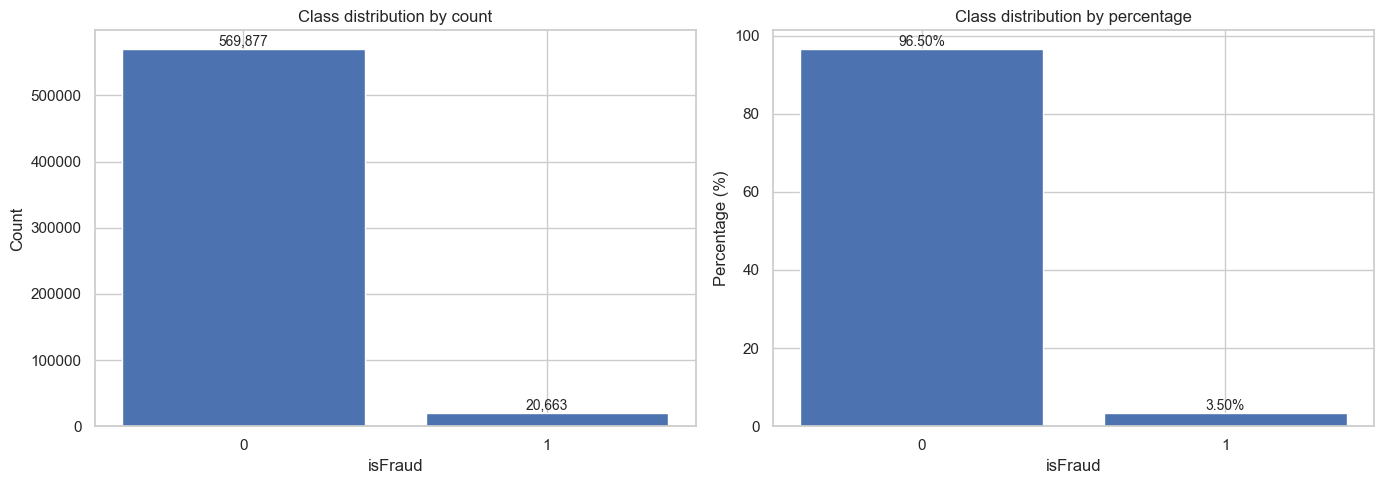

In [7]:
target_counts = df_eda[target_col].value_counts(dropna=False).sort_index()
target_ratio = df_eda[target_col].value_counts(dropna=False, normalize=True).sort_index()

fraud_count = int((df_eda[target_col] == positive_class).sum())
nonfraud_count = int((df_eda[target_col] != positive_class).sum())
fraud_ratio = fraud_count / len(df_eda)
imbalance_ratio = nonfraud_count / max(fraud_count, 1)

target_table = pd.DataFrame(
    {
        "class_value": target_counts.index.tolist(),
        "count": target_counts.values,
        "ratio": target_ratio.values,
        "ratio_pct": target_ratio.values * 100,
    }
)

metric_reference = pd.DataFrame(
    {
        "metric": [
            "positive_class_prevalence",
            "nonfraud_to_fraud_ratio",
            "accuracy_if_always_predict_nonfraud",
            "random_classifier_pr_auc_baseline",
        ],
        "value": [
            fraud_ratio,
            imbalance_ratio,
            1 - fraud_ratio,
            fraud_ratio,
        ],
    }
)

display(target_table)
display(metric_reference)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(target_table["class_value"].astype(str), target_table["count"])
axes[0].set_title("Class distribution by count")
axes[0].set_xlabel(target_col)
axes[0].set_ylabel("Count")

axes[1].bar(target_table["class_value"].astype(str), target_table["ratio_pct"])
axes[1].set_title("Class distribution by percentage")
axes[1].set_xlabel(target_col)
axes[1].set_ylabel("Percentage (%)")

for i, row in target_table.iterrows():
    axes[0].text(i, row["count"], f'{int(row["count"]):,}', ha="center", va="bottom", fontsize=10)
    axes[1].text(i, row["ratio_pct"], f'{row["ratio_pct"]:.2f}%', ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


### Phân tích kết quả

- Tỷ lệ fraud hiện tại chỉ khoảng **3,499%**, trong khi non-fraud chiếm **96,501%**. Đây là một mức mất cân bằng lớp rất mạnh, đủ để làm cho nhiều metric trực quan trở nên gây hiểu nhầm.
- Tỷ lệ non-fraud / fraud khoảng **27,58 : 1** nghĩa là trong dữ liệu gốc, cứ hơn 27 giao dịch bình thường mới có 1 giao dịch gian lận. Với cấu trúc như vậy, bài toán không phải chỉ là “phân loại đúng nhiều”, mà là **kéo được fraud lên mà không phá precision quá mạnh**.
- Nếu luôn dự đoán “không fraud”, accuracy đã đạt **96,50%**. Insight quan trọng ở đây là: một mô hình có accuracy rất cao vẫn hoàn toàn có thể **không có giá trị phát hiện fraud**.
- PR-AUC baseline ngẫu nhiên xấp xỉ **0,035**, tức gần đúng fraud prevalence. Đây là mốc nền hợp lý hơn accuracy để so sánh hiệu quả mô hình về sau. Chỉ cần vượt xa mức này đã là dấu hiệu mô hình học được tín hiệu thực sự.

## Missing Value Analysis

,table,columns_missing_ge_50pct,columns_missing_ge_90pct,columns_missing_ge_95pct
0,train_transaction,174,2,0
1,train_identity,12,9,9
2,df_eda,214,12,9


,feature,missing_count,missing_pct,dtype,nunique
0,dist2,552913,0.9363,float32,1751
1,D7,551623,0.9341,float32,597
2,D13,528588,0.8951,float32,577
3,D14,528353,0.8947,float32,802
4,D12,525823,0.8904,float32,635
5,D6,517353,0.8761,float32,829
6,D8,515614,0.8731,float32,12353
7,D9,515614,0.8731,float32,24
8,V138,508595,0.8612,float32,23
9,V139,508595,0.8612,float32,34


,feature,missing_count,missing_pct,dtype,nunique
0,id_24,139486,0.9671,float32,12
1,id_25,139101,0.9644,float32,341
2,id_07,139078,0.9643,float32,84
3,id_08,139078,0.9643,float32,94
4,id_21,139074,0.9642,float32,490
5,id_26,139070,0.9642,float32,95
6,id_22,139064,0.9642,float32,25
7,id_23,139064,0.9642,category,3
8,id_27,139064,0.9642,category,2
9,id_18,99120,0.6872,float32,18


,feature,missing_count,missing_pct,dtype,nunique
0,id_24,585793,0.9920,float32,12
1,id_25,585408,0.9913,float32,341
2,id_07,585385,0.9913,float32,84
3,id_08,585385,0.9913,float32,94
4,id_21,585381,0.9913,float32,490
5,id_26,585377,0.9913,float32,95
6,id_22,585371,0.9912,float32,25
7,id_23,585371,0.9912,category,3
8,id_27,585371,0.9912,category,2
9,dist2,552913,0.9363,float32,1751


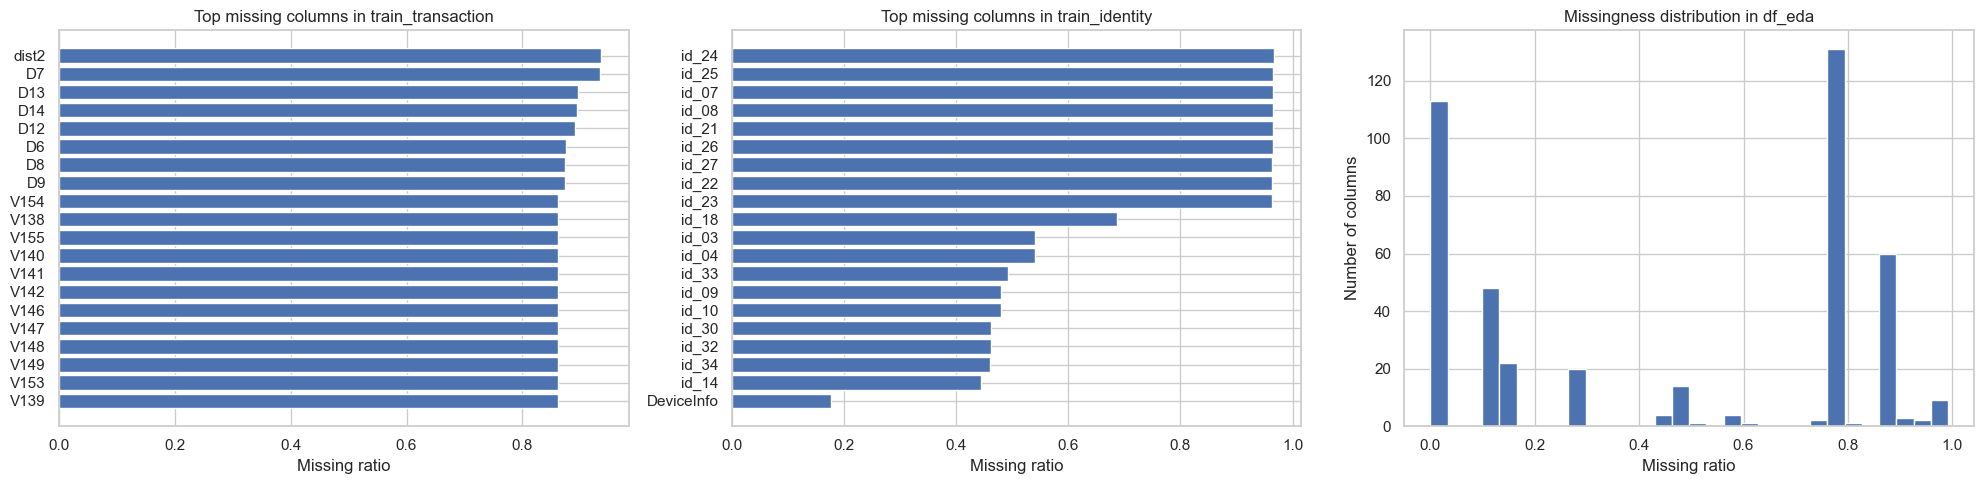

In [8]:
missing_transaction = missing_summary(train_transaction)
missing_identity = missing_summary(train_identity)
missing_eda = missing_summary(df_eda)

missing_threshold_summary = pd.DataFrame(
    [
        {
            "table": "train_transaction",
            "columns_missing_ge_50pct": int((missing_transaction["missing_pct"] >= 0.50).sum()),
            "columns_missing_ge_90pct": int((missing_transaction["missing_pct"] >= 0.90).sum()),
            "columns_missing_ge_95pct": int((missing_transaction["missing_pct"] >= 0.95).sum()),
        },
        {
            "table": "train_identity",
            "columns_missing_ge_50pct": int((missing_identity["missing_pct"] >= 0.50).sum()),
            "columns_missing_ge_90pct": int((missing_identity["missing_pct"] >= 0.90).sum()),
            "columns_missing_ge_95pct": int((missing_identity["missing_pct"] >= 0.95).sum()),
        },
        {
            "table": "df_eda",
            "columns_missing_ge_50pct": int((missing_eda["missing_pct"] >= 0.50).sum()),
            "columns_missing_ge_90pct": int((missing_eda["missing_pct"] >= 0.90).sum()),
            "columns_missing_ge_95pct": int((missing_eda["missing_pct"] >= 0.95).sum()),
        },
    ]
)

display(missing_threshold_summary)

display(missing_transaction.head(20))
display(missing_identity.head(20))
display(missing_eda.head(30))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

tx_plot = missing_transaction.head(20).sort_values("missing_pct", ascending=True)
axes[0].barh(tx_plot["feature"], tx_plot["missing_pct"])
axes[0].set_title("Top missing columns in train_transaction")
axes[0].set_xlabel("Missing ratio")

id_plot = missing_identity.head(20).sort_values("missing_pct", ascending=True)
axes[1].barh(id_plot["feature"], id_plot["missing_pct"])
axes[1].set_title("Top missing columns in train_identity")
axes[1].set_xlabel("Missing ratio")

axes[2].hist(missing_eda["missing_pct"], bins=30)
axes[2].set_title("Missingness distribution in df_eda")
axes[2].set_xlabel("Missing ratio")
axes[2].set_ylabel("Number of columns")

plt.tight_layout()
plt.show()


### Phân tích kết quả

- Ở mức bảng tổng:
  - `df_eda` có **214 cột thiếu từ 50% trở lên**
  - **12 cột thiếu từ 90% trở lên**
  - **9 cột thiếu từ 95% trở lên**

  Điều này cho thấy sparsity không phải là ngoại lệ, mà là **đặc điểm bản chất** của bộ dữ liệu.
- Trong `train_transaction`, các cột thiếu nhiều nhất tập trung ở `dist2`, `D7`, `D13`, `D14`, `D12`, `D6`, `D8`, `D9` và một block `V138`–`V155`. Việc thiếu cụm như vậy thường phản ánh **các trường chỉ được ghi nhận trong một số hoàn cảnh giao dịch nhất định**, chứ không giống lỗi nhập liệu rời rạc.
- Trong `train_identity`, hàng loạt cột `id_24`, `id_25`, `id_07`, `id_08`, `id_21`, `id_26`, `id_22`, `id_23`, `id_27` có missing trên **96%**. Khi merge sang `df_eda`, các cột này lên đến khoảng **99% missing** vì identity vốn chỉ phủ được một phần nhỏ transaction rows.
- Một insight rất đáng chú ý là: **missing cao không đồng nghĩa ít thông tin**. Ví dụ:
  - `dist2` vẫn có **1.751** giá trị phân biệt
  - `D8` có tới **12.353** giá trị phân biệt
  - `id_25` có **341** giá trị phân biệt

  Nghĩa là phần “không missing” của các cột này có thể chứa tín hiệu phong phú, dù tỷ lệ xuất hiện thấp.

,feature,overall_missing_pct,fraud_missing_pct,nonfraud_missing_pct,missing_gap,abs_missing_gap,fraud_rate_if_missing,fraud_rate_if_present
0,R_emaildomain,0.7675,0.4567,0.7788,-0.3221,0.3221,0.0208,0.0818
1,id_02,0.7615,0.4569,0.7725,-0.3156,0.3156,0.0210,0.0797
2,id_15,0.7613,0.4569,0.7723,-0.3154,0.3154,0.0210,0.0796
3,id_38,0.7613,0.4569,0.7723,-0.3154,0.3154,0.0210,0.0796
4,id_37,0.7613,0.4569,0.7723,-0.3154,0.3154,0.0210,0.0796
5,id_36,0.7613,0.4569,0.7723,-0.3154,0.3154,0.0210,0.0796
6,id_35,0.7613,0.4569,0.7723,-0.3154,0.3154,0.0210,0.0796
7,id_11,0.7613,0.4571,0.7723,-0.3152,0.3152,0.0210,0.0796
8,id_29,0.7613,0.4571,0.7723,-0.3152,0.3152,0.0210,0.0796
9,id_28,0.7613,0.4571,0.7723,-0.3152,0.3152,0.0210,0.0796


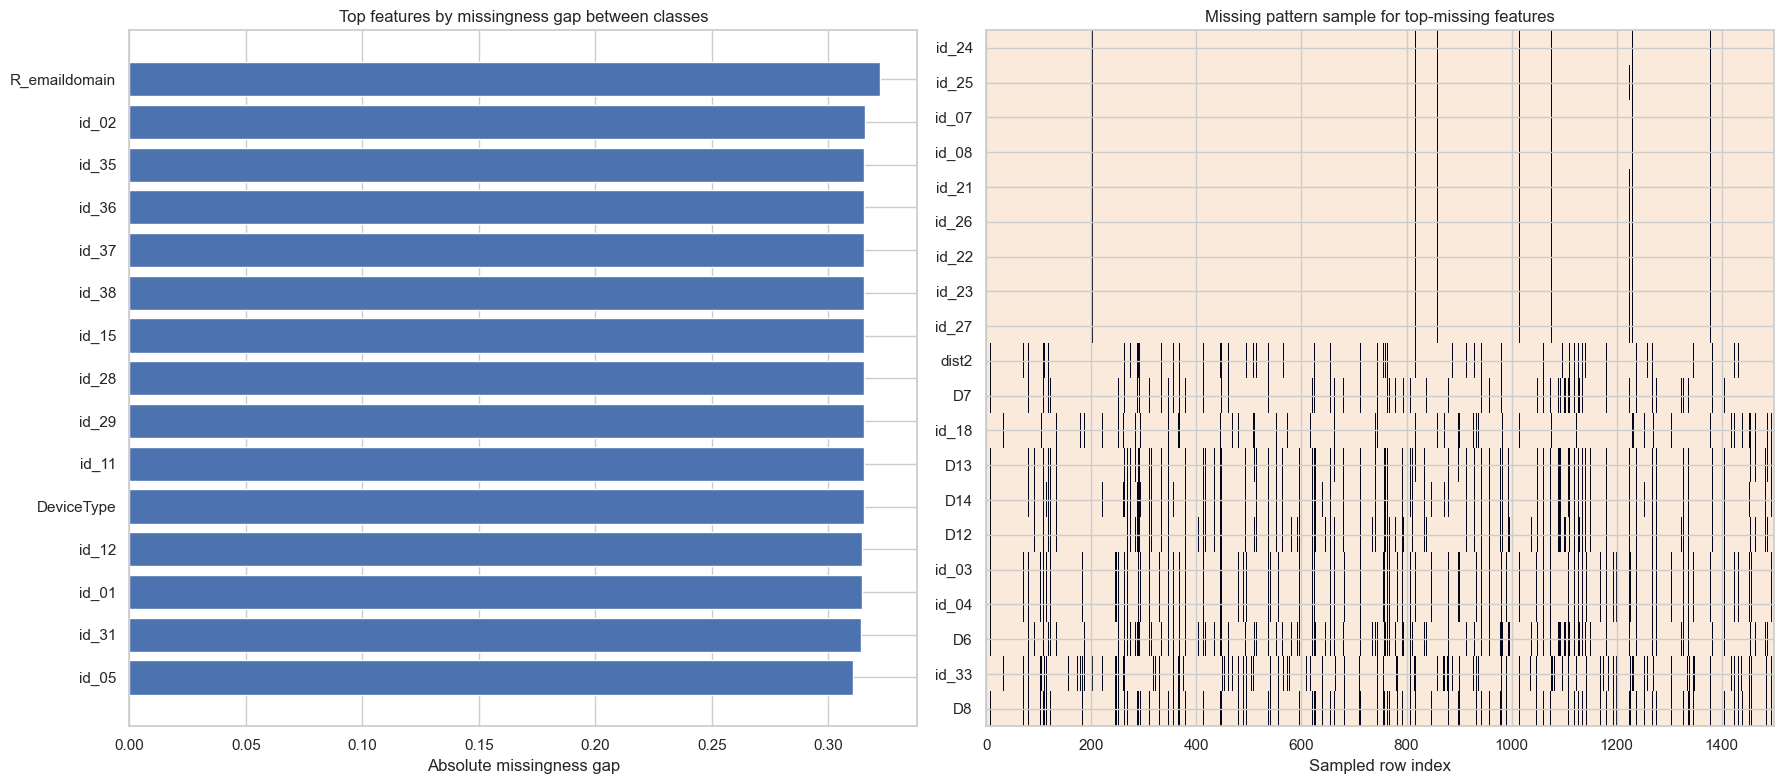

In [9]:
missing_signal_df = build_missing_signal_table(df_eda, target_col, positive_class)
display(missing_signal_df.head(20))

top_missing_pattern_features = missing_eda.head(20)["feature"].tolist()
missing_pattern_sample = safe_sample(df_eda[top_missing_pattern_features], n=min(1500, len(df_eda)))
missing_pattern_matrix = missing_pattern_sample.isna().astype(int).T

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plot_missing_gap = missing_signal_df.head(15).sort_values("abs_missing_gap", ascending=True)
axes[0].barh(plot_missing_gap["feature"], plot_missing_gap["abs_missing_gap"])
axes[0].set_title("Top features by missingness gap between classes")
axes[0].set_xlabel("Absolute missingness gap")

axes[1].imshow(missing_pattern_matrix, aspect="auto", interpolation="nearest")
axes[1].set_title("Missing pattern sample for top-missing features")
axes[1].set_xlabel("Sampled row index")
axes[1].set_yticks(range(len(top_missing_pattern_features)))
axes[1].set_yticklabels(top_missing_pattern_features)

plt.tight_layout()
plt.show()


### Phân tích kết quả

- Bảng missing signal cho thấy nhiều cột có **chênh lệch missingness theo class rất lớn**, khoảng **31–32 điểm phần trăm**. Các ví dụ nổi bật gồm:
  - `R_emaildomain`
  - `id_02`
  - `id_15`
  - `id_38`
  - `DeviceType`
  - `id_01`
- Với `R_emaildomain`, missing chung khoảng **76,75%**, nhưng:
  - fraud missing chỉ khoảng **45,67%**
  - non-fraud missing khoảng **77,88%**

  Đồng thời fraud rate trong nhóm bị missing chỉ khoảng **2,08%**, thấp hơn đáng kể so với baseline **3,50%**. Diễn giải thực tế: **khi trường này xuất hiện**, rủi ro fraud tăng lên rõ rệt; trạng thái “có dữ liệu” bản thân nó là tín hiệu.
- Cùng một mô hình lặp lại ở nhiều cột `id_*` và cả `DeviceType`, cho thấy đây không phải tín hiệu đơn lẻ mà là **một cơ chế capture chung**: giao dịch fraud có xu hướng đi kèm nhiều metadata hơn trong một số nhóm thông tin.
- Ma trận missing pattern ở cụm top-missing features cũng hỗ trợ nhận định rằng missing không phân bố ngẫu nhiên từng cột, mà xuất hiện theo **cụm đồng thời**. Điều này rất quan trọng cho preprocessing: nên giữ missing indicator hoặc để mô hình cây học trực tiếp, thay vì coi mọi `NaN` chỉ là giá trị cần lấp.

## Duplicate and Basic Inspection

In [10]:
duplicate_summary = pd.DataFrame(
    [
        {
            "table": "train_transaction",
            "duplicate_full_rows": int(train_transaction.duplicated().sum()),
            "duplicate_id_rows": int(train_transaction[id_col].duplicated().sum()) if id_col else np.nan,
        },
        {
            "table": "train_identity",
            "duplicate_full_rows": int(train_identity.duplicated().sum()),
            "duplicate_id_rows": int(train_identity[id_col].duplicated().sum()) if id_col and id_col in train_identity.columns else np.nan,
        },
        {
            "table": "df_eda",
            "duplicate_full_rows": int(df_eda.duplicated().sum()),
            "duplicate_id_rows": int(df_eda[id_col].duplicated().sum()) if id_col else np.nan,
        },
    ]
)

constant_columns = [col for col in df_eda.columns if df_eda[col].nunique(dropna=False) <= 1]

quasi_constant_columns = []
for col in df_eda.columns:
    distribution = df_eda[col].value_counts(dropna=False, normalize=True)
    if not distribution.empty and distribution.iloc[0] >= QUASI_CONSTANT_THRESHOLD:
        quasi_constant_columns.append(col)

infinite_value_count = 0
for col in eda_numeric_cols:
    values = pd.to_numeric(df_eda[col], errors="coerce")
    infinite_value_count += int(np.isinf(values).sum())

basic_inspection = pd.DataFrame(
    {
        "check": [
            "duplicate full rows in df_eda",
            f"duplicate {id_col}" if id_col else "duplicate id",
            "constant columns",
            f"quasi-constant columns (top frequency >= {QUASI_CONSTANT_THRESHOLD:.1%})",
            "numeric infinite values",
            "negative TransactionAmt",
            "zero TransactionAmt",
        ],
        "value": [
            int(df_eda.duplicated().sum()),
            int(df_eda[id_col].duplicated().sum()) if id_col else np.nan,
            len(constant_columns),
            len(quasi_constant_columns),
            infinite_value_count,
            int((df_eda["TransactionAmt"] < 0).sum()) if "TransactionAmt" in df_eda.columns else np.nan,
            int((df_eda["TransactionAmt"] == 0).sum()) if "TransactionAmt" in df_eda.columns else np.nan,
        ],
    }
)

display(duplicate_summary)
display(basic_inspection)
display(pd.DataFrame({"constant_columns": constant_columns[:30]}))
display(pd.DataFrame({"quasi_constant_columns": quasi_constant_columns[:30]}))


,table,duplicate_full_rows,duplicate_id_rows
0,train_transaction,0,0
1,train_identity,0,0
2,df_eda,0,0


,check,value
0,duplicate full rows in df_eda,0
1,duplicate TransactionID,0
2,constant columns,0
3,quasi-constant columns (top frequency >= 99.5%),11
4,numeric infinite values,0
5,negative TransactionAmt,0
6,zero TransactionAmt,0


,constant_columns


,quasi_constant_columns
0,C3
1,V107
2,V111
3,V113
4,V117
5,V118
6,V119
7,V120
8,V121
9,V122


### Phân tích kết quả

- Không có duplicate full rows và cũng không có duplicate `TransactionID` ở cả ba bảng. Đây là một điểm rất tốt vì nó loại bỏ sớm nguy cơ:
  - đếm lặp fraud prevalence,
  - nhân bản record khi join,
  - hoặc bias sai trong feature frequency.
- Không có constant column nào, cũng không có giá trị vô cực, không có `TransactionAmt` âm và cũng không có `TransactionAmt = 0`. Điều này cho thấy dữ liệu khá “sạch” ở tầng kiểm tra kỹ thuật cơ bản; notebook không cần dành nhiều công sức cho cleaning kiểu lỗi thô.
- Tuy nhiên có **11 quasi-constant columns**, gồm `C3`, `V107`, `V111`, `V113`, `V117`–`V122`, `V305`. Những cột này không hỏng, nhưng mức biến thiên thực tế rất thấp, nên xác suất đóng góp tín hiệu độc lập thường không cao.
- Insight thực hành ở đây là: giai đoạn preprocessing sau không cần tập trung vào de-dup hay xử lý invalid numeric, mà nên tập trung vào **missingness, skewness, redundancy và target separation**.

## Descriptive Statistics

In [11]:
numeric_profile_df = numeric_profile(df_eda, eda_numeric_cols)
categorical_profile_df = categorical_profile(df_eda, eda_categorical_cols)

display(numeric_profile_df.head(40))
display(categorical_profile_df.head(40))


,feature,missing_pct,nunique,mean,std,min,p01,p50,p99,max,skew,zero_pct,negative_pct,abs_skew
0,id_24,0.9920,12,12.8009,2.3725,11.0000,11.0000,11.0000,21.0000,26.0000,1.2939,0.0000,0.0000,1.2939
1,id_25,0.9913,341,329.6089,97.4626,100.0000,113.0000,321.0000,528.0000,548.0000,0.0459,0.0000,0.0000,0.0459
2,id_08,0.9913,94,-38.6004,26.0850,-100.0000,-100.0000,-34.0000,0.0000,0.0000,-1.0161,0.0004,0.0083,1.0161
3,id_07,0.9913,84,13.2854,11.3842,-46.0000,-14.4600,14.0000,39.0000,61.0000,-0.1606,0.0007,0.0006,0.1606
4,id_21,0.9913,490,368.2698,198.8490,100.0000,131.0000,252.0000,849.0000,854.0000,1.2426,0.0000,0.0000,1.2426
5,id_26,0.9913,95,149.0703,32.1019,100.0000,100.0000,149.0000,216.0000,216.0000,0.0073,0.0000,0.0000,0.0073
6,id_22,0.9912,25,16.0027,6.8978,10.0000,14.0000,14.0000,41.0000,44.0000,3.2316,0.0000,0.0000,3.2316
7,dist2,0.9363,1751,231.8554,529.0393,0.0000,0.0000,37.0000,"2,367.4800","11,623.0000",5.9725,0.0060,0.0000,5.9725
8,D7,0.9341,597,41.6390,99.7320,0.0000,0.0000,0.0000,429.0000,843.0000,2.9503,0.0358,0.0000,2.9503
9,id_18,0.9236,18,14.2373,1.5611,10.0000,12.0000,15.0000,20.0000,29.0000,2.0747,0.0000,0.0000,2.0747


,feature,dtype,missing_pct,nunique,top_value,top_freq_pct
0,id_23,category,0.9912,3,MISSING,0.9912
1,id_27,category,0.9912,2,MISSING,0.9912
2,id_33,category,0.8759,260,MISSING,0.8759
3,id_30,category,0.8687,75,MISSING,0.8687
4,id_34,category,0.8682,4,MISSING,0.8682
5,DeviceInfo,category,0.7991,1786,MISSING,0.7991
6,id_16,category,0.7810,2,MISSING,0.7810
7,R_emaildomain,category,0.7675,60,MISSING,0.7675
8,id_31,category,0.7625,130,MISSING,0.7625
9,DeviceType,category,0.7616,2,MISSING,0.7616


### Phân tích kết quả

- Bảng numeric profile mở đầu bằng các cột cực kỳ sparse như `id_24`, `id_25`, `id_08`, `id_07`, `id_21`, `id_26`, `dist2`, `D7`, `D13`, `D14`. Điều này xác nhận lại một lần nữa rằng merged dataset có một lớp biến chỉ xuất hiện trong các tình huống rất chọn lọc.
- Nhiều cột số có cấu trúc phân phối khá đặc biệt:
  - phần lớn quantile thấp (`p01`, `p50`) bằng **0**
  - nhưng `max` lại rất lớn
  - đôi khi có cả giá trị âm

  Đây là kiểu phân phối “**spike at zero + long tail**”, rất phổ biến trong fraud datasets và thường phù hợp hơn với mô hình cây hoặc các transform phi tuyến.
- Ở bảng categorical profile, nhiều cột bị chi phối bởi hẳn một mức `MISSING`, ví dụ:
  - `id_23`, `id_27`: ~99%
  - `id_33`, `id_30`, `id_34`
  - `DeviceInfo`, `R_emaildomain`, `DeviceType`

  Tức là với nhiều biến categorical, “thiếu dữ liệu” thực chất đang là **một category cực lớn**, chứ không chỉ là một ô trống.
- Ngược lại, các cột như `ProductCD`, `card4`, `card6` có missing rất thấp, cardinality nhỏ và phân phối ổn định hơn. Đây là nhóm biến rất phù hợp để làm **anchor features** khi xây baseline model hoặc bảng fraud-rate theo nhóm.

## Univariate Analysis

In [12]:
selected_numeric_features, separation_table_full, numeric_anomaly_df = select_numeric_features(
    df_eda,
    eda_numeric_cols,
    target_col,
    positive_class,
    max_features=MAX_UNIVARIATE_NUMERIC,
)

selected_categorical_features = select_categorical_features(
    df_eda,
    eda_categorical_cols,
    max_features=MAX_UNIVARIATE_CATEGORICAL,
)

display(pd.DataFrame({"selected_numeric_features": selected_numeric_features}))
display(pd.DataFrame({"selected_categorical_features": selected_categorical_features}))
display(separation_table_full.head(20))
display(
    numeric_anomaly_df.sort_values("abs_skew", ascending=False)
    .head(20)
)


,selected_numeric_features
0,TransactionAmt
1,TransactionDT
2,card1
3,card2
4,card3
5,card5
6,addr1
7,addr2


,selected_categorical_features
0,ProductCD
1,card4
2,card6
3,P_emaildomain
4,R_emaildomain
5,DeviceType


,feature,ks_stat,norm_median_gap,abs_target_corr,missing_pct,fraud_mean,nonfraud_mean,fraud_median,nonfraud_median
0,V258,0.4679,0.5000,0.2452,0.7791,3.4151,1.2174,2.0000,1.0000
1,V257,0.4385,1.0000,0.2501,0.7791,2.9698,1.1122,2.0000,1.0000
2,D5,0.4355,0.6250,0.1979,0.5247,13.8545,43.0959,0.0000,10.0000
3,V265,0.4210,0.3669,0.0551,0.7791,232.2929,130.4737,62.3810,0.0000
4,V264,0.4205,0.3942,0.0236,0.7791,274.5869,197.5187,78.8481,0.0000
5,V219,0.4194,0.3333,0.2049,0.7791,3.2863,0.8333,1.0000,0.0000
6,V218,0.4181,0.6667,0.1662,0.7791,4.0145,1.1989,2.0000,0.0000
7,V274,0.4068,0.2019,0.0628,0.7791,174.6187,83.2219,20.7844,0.0000
8,V232,0.4062,0.5000,0.2050,0.7791,2.9833,0.5006,1.0000,0.0000
9,V246,0.4035,0.0000,0.2393,0.7791,2.4993,1.0817,1.0000,1.0000


,feature,missing_pct,nunique,mean,std,min,p01,p50,p99,max,skew,zero_pct,negative_pct,abs_skew
352,V311,0.0000,3098,4.2022,102.3317,0.0000,0.0000,0.0000,105.0000,"55,125.0000",323.8314,0.9708,0.0000,323.8314
309,V129,0.0005,1968,8.7689,113.6135,0.0000,0.0000,0.0000,214.0000,"55,125.0000",240.2743,0.9460,0.0000,240.2743
353,V309,0.0000,4236,10.9960,115.9602,0.0000,0.0000,0.0000,226.0000,"55,125.0000",224.8753,0.9238,0.0000,224.8753
121,V206,0.7636,1780,6.1894,191.4212,0.0000,0.0000,0.0000,100.0428,"55,125.0000",207.8816,0.2250,0.0000,207.8816
354,V319,0.0000,4799,18.3725,331.8374,0.0000,0.0000,0.0000,448.0000,"104,060.0000",181.8336,0.9529,0.0000,181.8336
70,V269,0.7791,151,5.9975,207.2898,0.0000,0.0000,0.0000,100.0000,"55,125.0000",177.8389,0.2172,0.0000,177.8389
71,V266,0.7791,2178,9.1678,207.9367,0.0000,0.0000,0.0000,150.0000,"55,125.0000",175.9588,0.2041,0.0000,175.9588
51,V334,0.8605,143,9.8070,243.7876,0.0000,0.0000,0.0000,200.0000,"55,125.0000",168.4728,0.1331,0.0000,168.4728
310,V135,0.0005,3724,17.2501,293.6629,0.0000,0.0000,0.0000,400.0000,"90,750.0000",144.8832,0.9543,0.0000,144.8832
355,V321,0.0000,5560,28.3266,381.3282,0.0000,0.0000,0.0000,561.0000,"104,060.0000",123.5565,0.9409,0.0000,123.5565


### Phân tích kết quả

- Nhóm biến được chọn để quan sát trực quan gồm:
  - numeric dễ diễn giải: `TransactionAmt`, `TransactionDT`, `card1`, `card2`, `card3`, `card5`, `addr1`, `addr2`
  - categorical dễ diễn giải: `ProductCD`, `card4`, `card6`, `P_emaildomain`, `R_emaildomain`, `DeviceType`

  Đây là lựa chọn hợp lý vì chúng vừa có ý nghĩa nghiệp vụ, vừa giúp nhìn dữ liệu ở góc dễ hiểu trước khi đi vào các block `V*` khó diễn giải hơn.
- Bảng separation ranking cho thấy các biến nổi bật nhất lại chủ yếu nằm ở block `V*` và `D5`, đặc biệt:
  - `V258`, `V257`, `D5`, `V265`, `V264`, `V219`, `V218`, `V274`, `V232`, `V246`
- Một đặc điểm rất đáng chú ý là nhiều biến top signal cùng có `missing_pct ≈ 0,7791`. Điều này gợi ý rằng chúng thuộc về **một cụm feature được kích hoạt cùng nhau**, và khi xuất hiện thì khả năng phân biệt fraud tăng mạnh.
- `V257`, `V258`, `V246` nổi bật vì vừa có `ks_stat` cao vừa có `abs_target_corr` khá mạnh. Riêng `V51` và `V52` ở phía dưới top 20 còn thú vị hơn ở chỗ:
  - missing thấp hơn đáng kể (**28,61%**)
  - nhưng `abs_target_corr` lại rất cao (**~0,39** và **~0,37**)

  Đây có thể là nhóm feature mạnh hơn về tính triển khai thực tế vì ít sparse hơn.
- Bảng numeric anomalies cho thấy rất nhiều `V*` có:
  - median = 0
  - zero_pct cực cao
  - skewness khổng lồ
  - max lên tới hàng chục nghìn

  Điều này cho thấy nếu dùng mô hình không phải tree-based, việc transform / clipping / scaling sẽ cực kỳ quan trọng; còn nếu dùng mô hình cây, raw sparsity và tail behavior có thể lại chính là lợi thế.

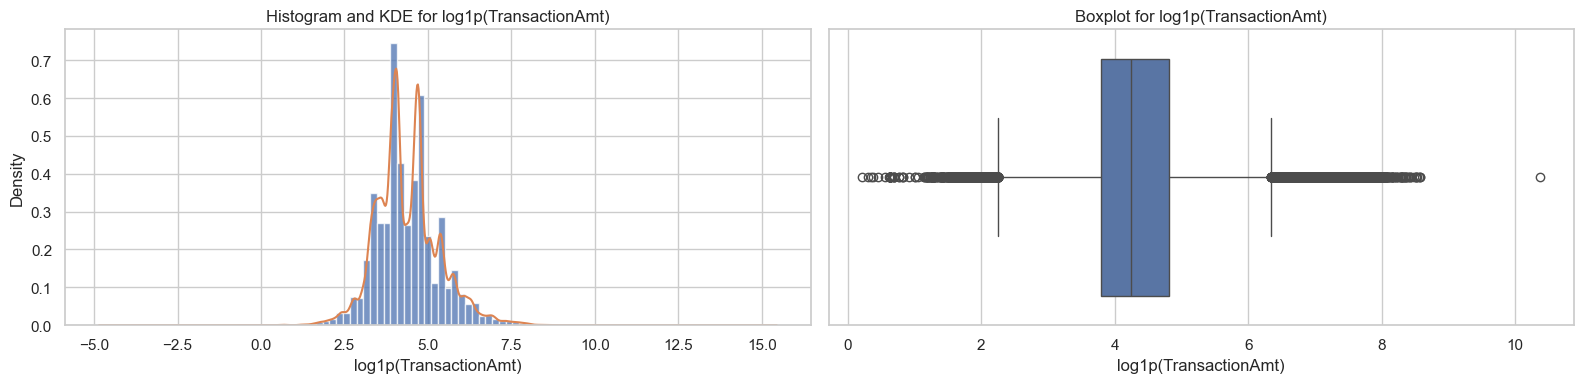

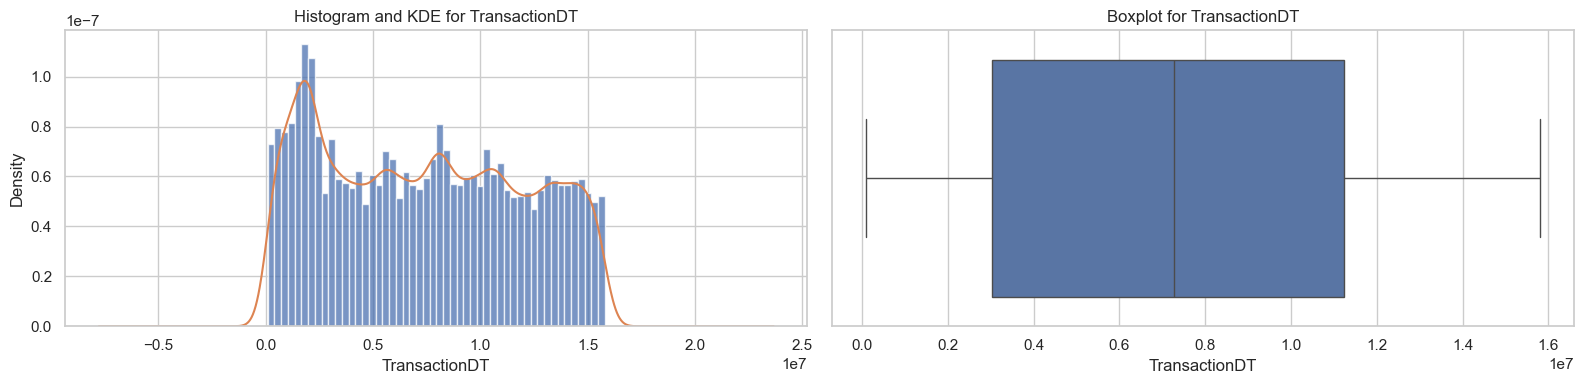

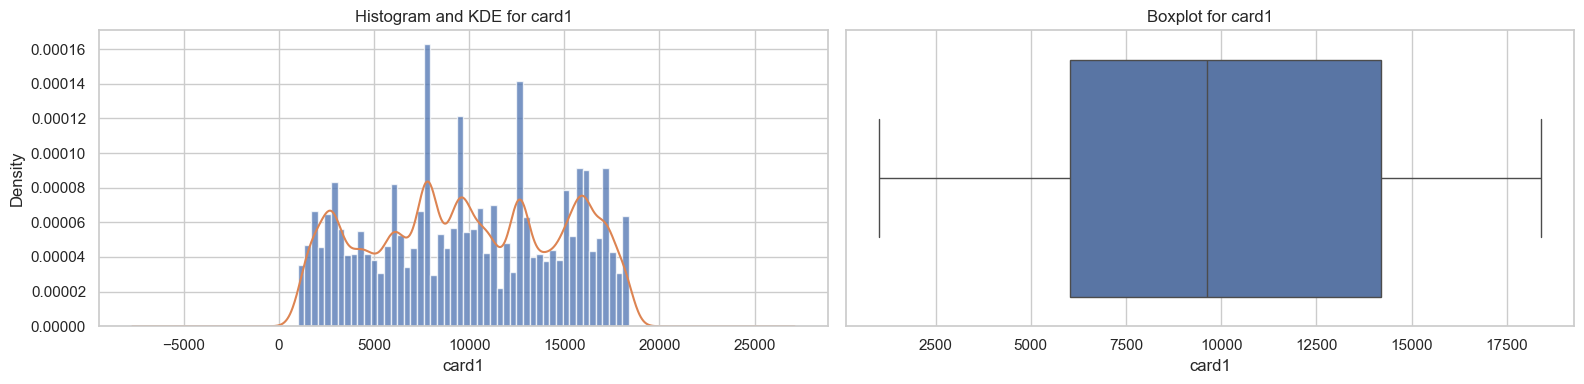

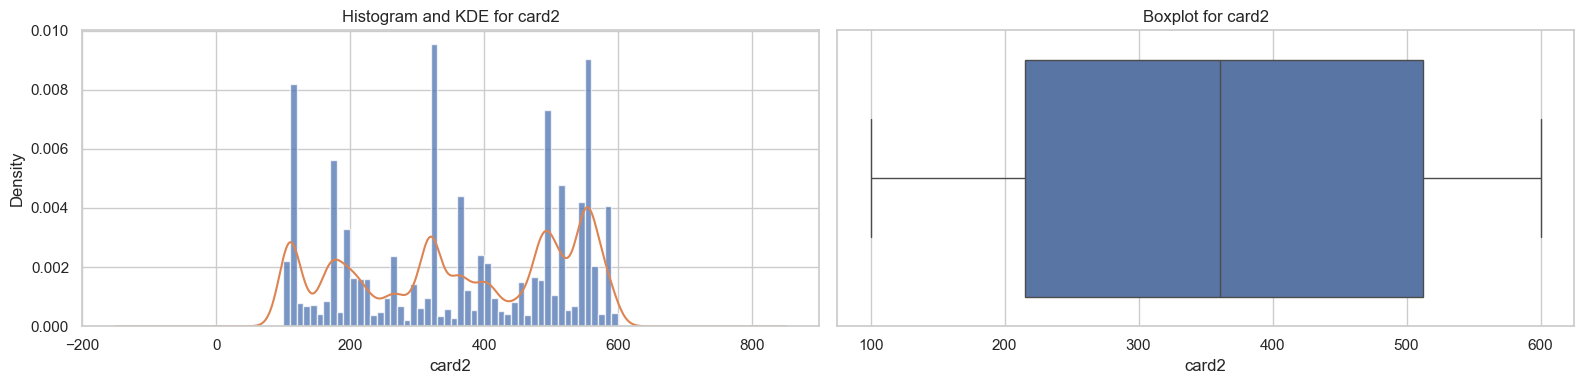

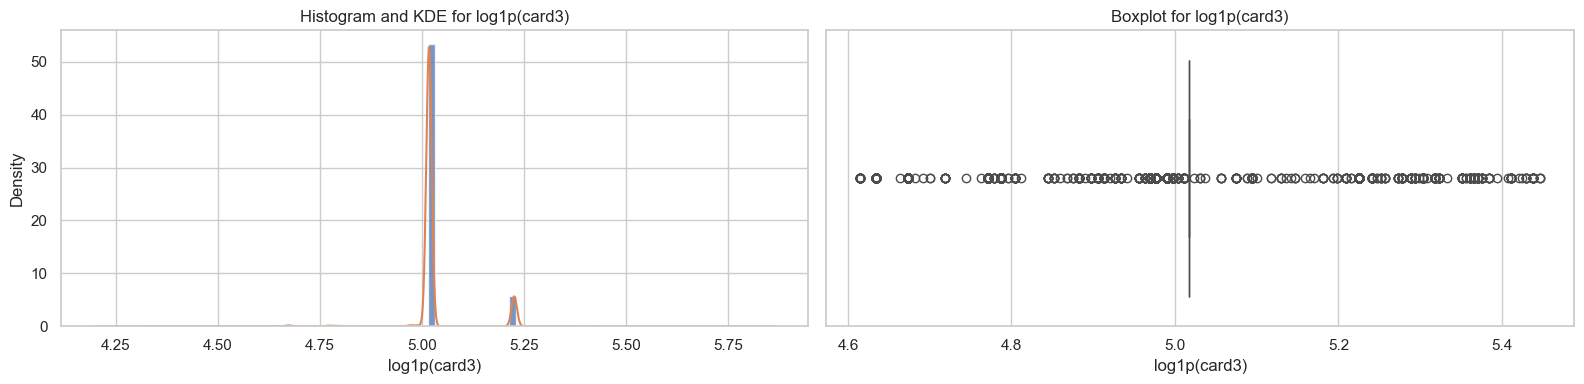

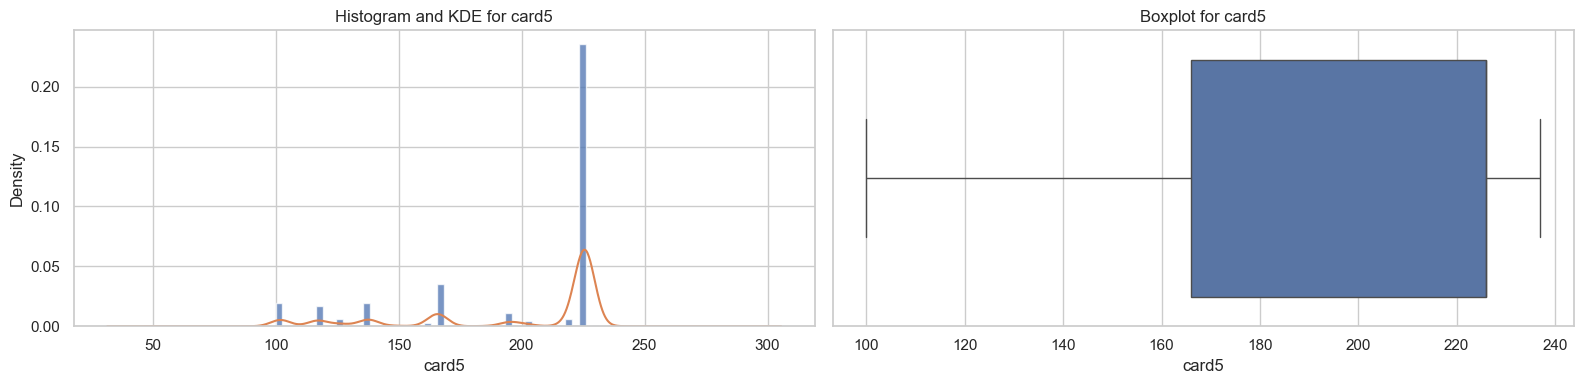

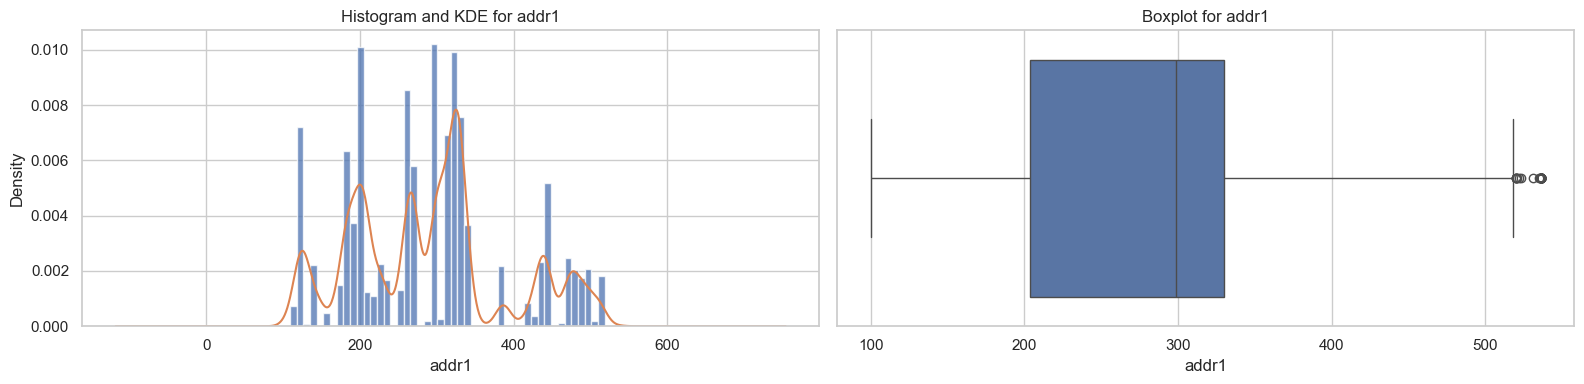

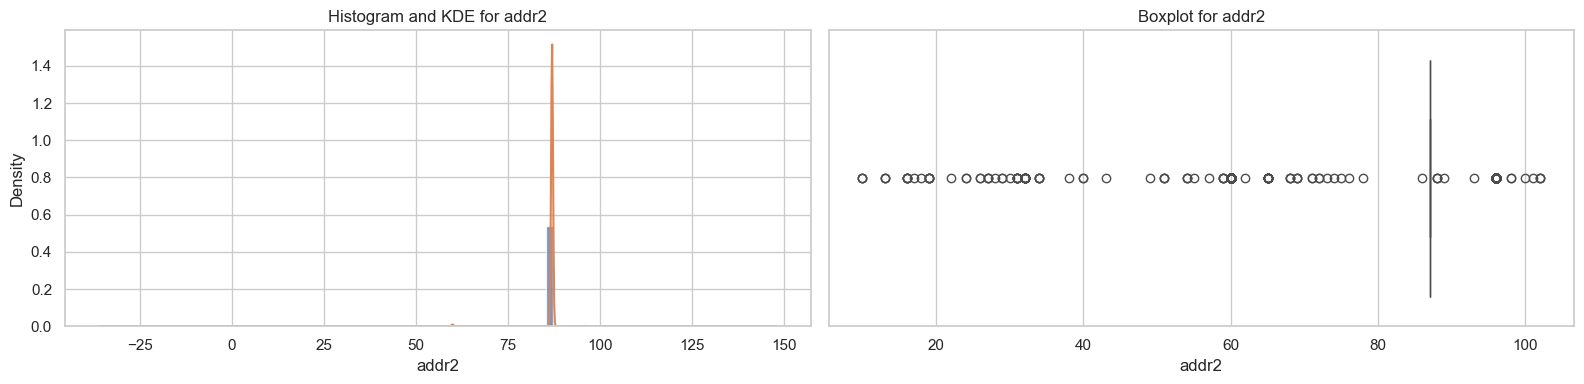

In [13]:
univariate_plot_df = safe_sample(df_eda[selected_numeric_features], n=min(PLOT_SAMPLE_SIZE, len(df_eda)))

for feature in selected_numeric_features:
    values = pd.to_numeric(univariate_plot_df[feature], errors="coerce").dropna()
    if values.empty:
        continue

    plot_values = values.copy()
    feature_label = feature

    if values.min() >= 0 and values.skew() > 2:
        plot_values = np.log1p(values)
        feature_label = f"log1p({feature})"

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    axes[0].hist(plot_values, bins=50, density=True, alpha=0.75)
    plot_values.plot(kind="kde", ax=axes[0])
    axes[0].set_title(f"Histogram and KDE for {feature_label}")
    axes[0].set_xlabel(feature_label)

    sns.boxplot(x=plot_values, ax=axes[1], orient="h")
    axes[1].set_title(f"Boxplot for {feature_label}")
    axes[1].set_xlabel(feature_label)

    plt.tight_layout()
    plt.show()


### Phân tích kết quả

- Ở nhóm numeric dễ diễn giải, cấu trúc phân phối nhìn chung không “mượt” theo nghĩa thống kê cổ điển:
  - `TransactionAmt` có đuôi phải dài, nhiều giao dịch giá trị nhỏ nhưng vẫn có một số giao dịch rất lớn kéo lệch phân phối.
  - `TransactionDT` trải dài theo trục thời gian, nên hình dạng phân phối của nó phản ánh **dòng thời gian giao dịch** hơn là một biến numeric để đọc theo mean / std thông thường.
- Các biến như `card1`, `card2`, `card3`, `card5`, `addr1`, `addr2` dù là numeric nhưng thực chất mang tính **mã định danh / mã nhóm** nhiều hơn là đại lượng liên tục. Vì vậy:
  - histogram thường xuất hiện nhiều “spike”
  - boxplot tạo cảm giác có nhiều outlier, nhưng nhiều điểm cực trị ở đây là do tính rời rạc của mã chứ không hẳn là lỗi dữ liệu
- Insight thực hành là: với nhóm numeric-ID kiểu này, không nên áp dụng trực giác của biến liên tục thuần túy. Cách xử lý phù hợp hơn thường là:
  - để mô hình cây tự split,
  - hoặc dùng frequency / target encoding ở pipeline sau,
  thay vì đọc chênh lệch khoảng cách giữa các giá trị như một biến đo lường thông thường.
- Việc boxplot cho thấy rất nhiều điểm ở ngoài vùng thân phân phối cũng củng cố nhận định rằng dataset này chứa nhiều tail values; tuy nhiên đó là phần tín hiệu cần **giữ để phân tích**, không phải mặc định loại bỏ.

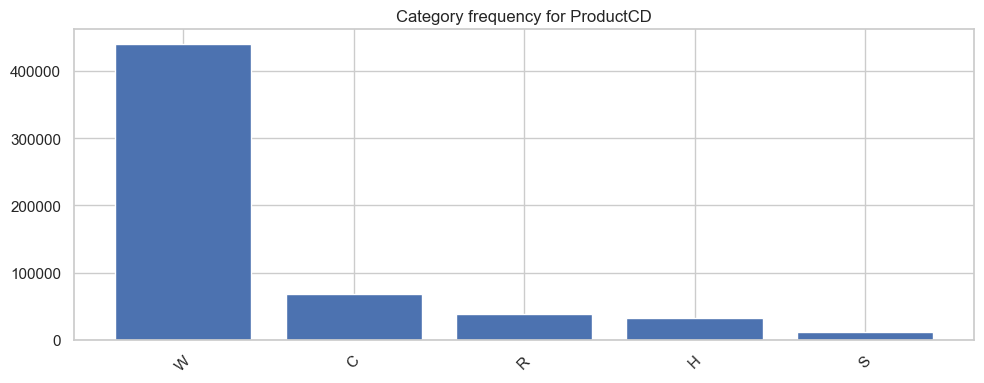

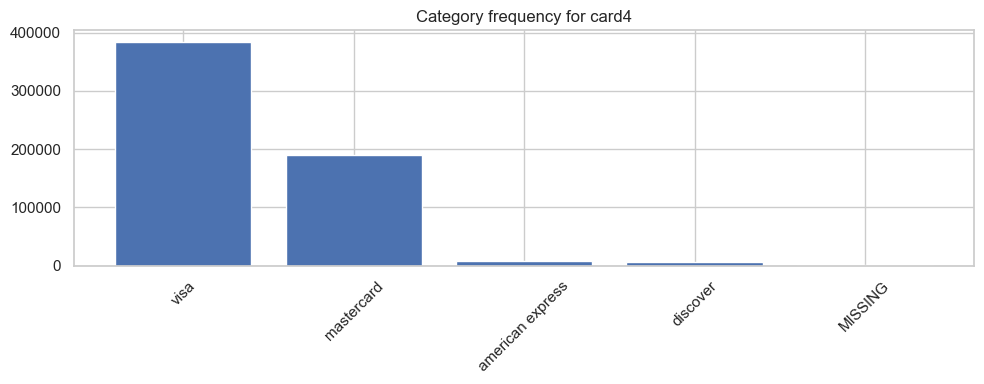

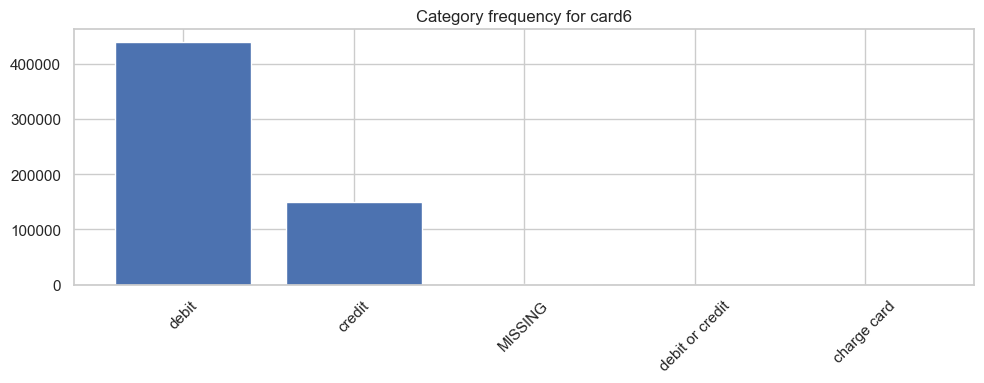

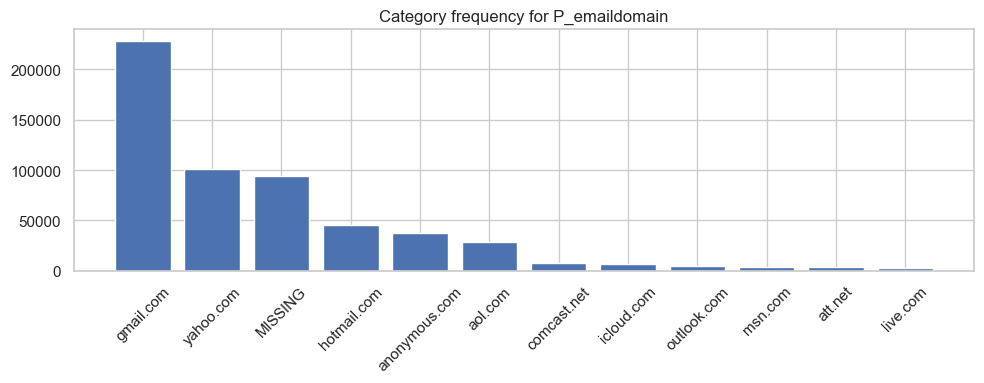

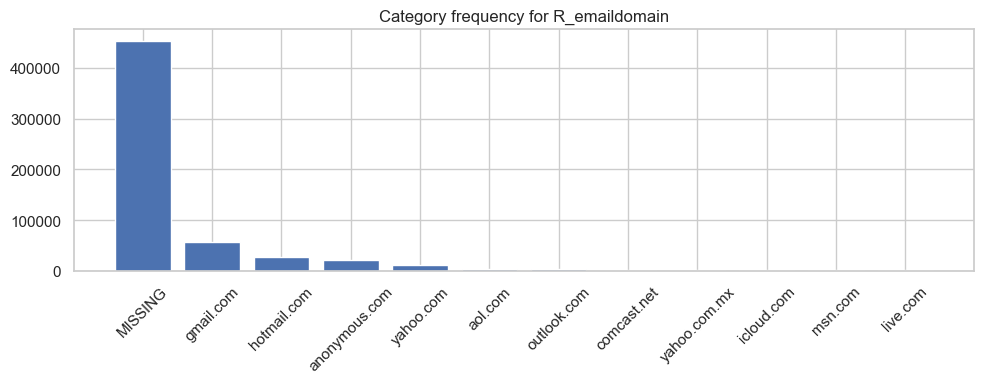

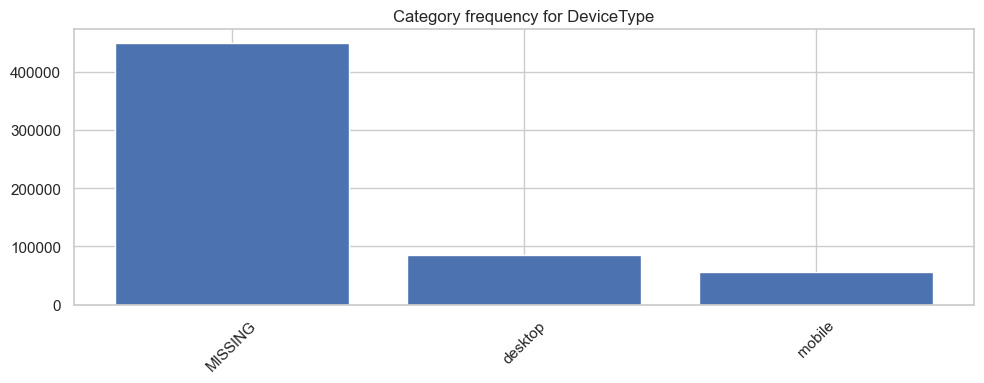

In [14]:
for feature in selected_categorical_features:
    counts = (
        df_eda[feature]
        .astype("string")
        .fillna("MISSING")
        .value_counts()
        .head(12)
        .reset_index()
    )
    counts.columns = [feature, "count"]

    plt.figure(figsize=(10, 4))
    plt.bar(counts[feature].astype(str), counts["count"])
    plt.title(f"Category frequency for {feature}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Phân tích kết quả

- Frequency plots cho thấy các biến categorical được chọn đều có mức độ tập trung khá cao:
  - `ProductCD` bị chi phối mạnh bởi một vài nhóm lớn
  - `card4` tập trung chủ yếu vào `visa` và `mastercard`
  - `card6` chủ yếu là `debit`
  - `P_emaildomain` nghiêng mạnh về `gmail.com`
  - `R_emaildomain` và `DeviceType` có một khối `MISSING` rất lớn
- Điều này mang hai ý nghĩa:
  1. các category lớn sẽ quyết định phần lớn volume giao dịch;
  2. các category nhỏ có thể mang fraud rate rất khác biệt nhưng dễ bất ổn nếu không đủ count.
- Sự xuất hiện của một category `MISSING` chiếm tỷ trọng lớn ở nhiều biến cho thấy missing cần được xem như **một trạng thái nghiệp vụ**. Nếu ép impute hoặc xóa đi, ta có thể làm mất đi một phần tín hiệu phân tách rất mạnh.
- Với những biến categorical dạng này, chiến lược gộp tail categories thành `OTHER` trong modeling sau là hợp lý, nhưng vẫn phải giữ riêng `MISSING` nếu nó thể hiện hành vi dữ liệu khác biệt.

## Fraud vs Non-Fraud Comparison

,top_compare_features
0,V258
1,V257
2,D5
3,V265
4,V264
5,V219


,feature,missing_pct_fraud,missing_pct_nonfraud,fraud_minus_nonfraud_missing_pct
0,V258,0.5068,0.7890,-0.2823
1,V257,0.5068,0.7890,-0.2823
3,V265,0.5068,0.7890,-0.2823
4,V264,0.5068,0.7890,-0.2823
5,V219,0.5068,0.7890,-0.2823
2,D5,0.4735,0.5265,-0.0531


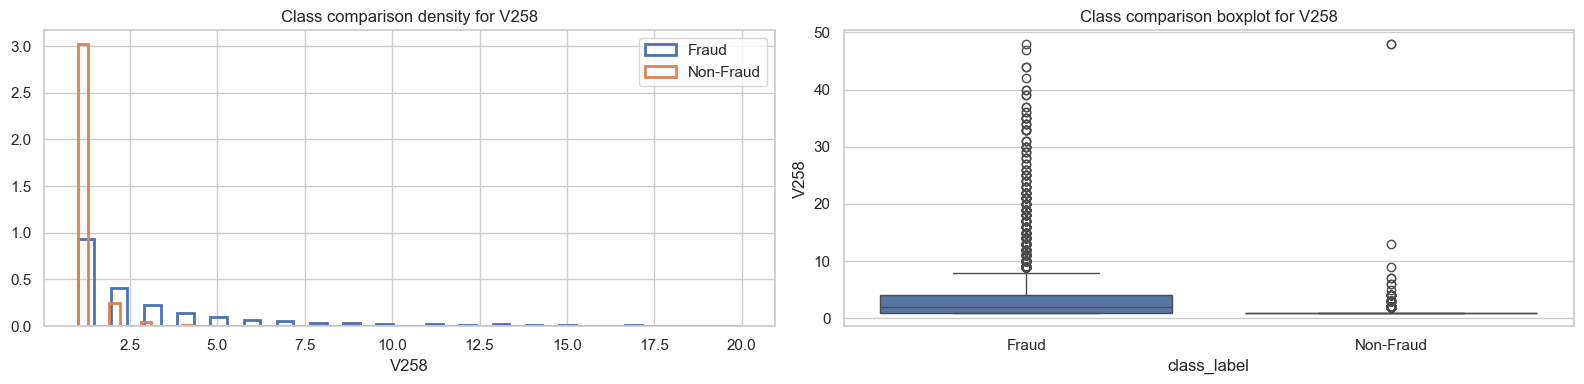

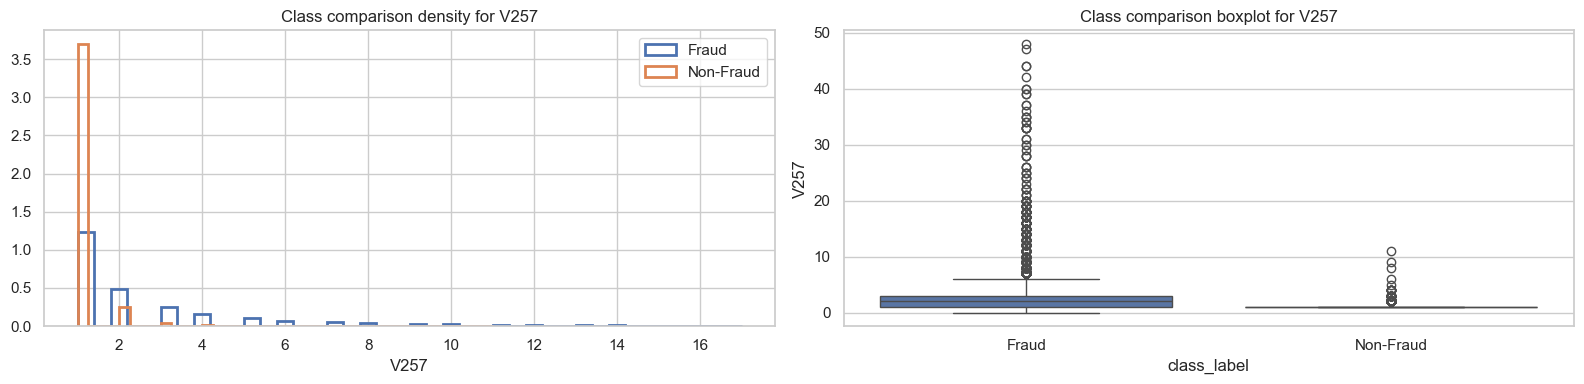

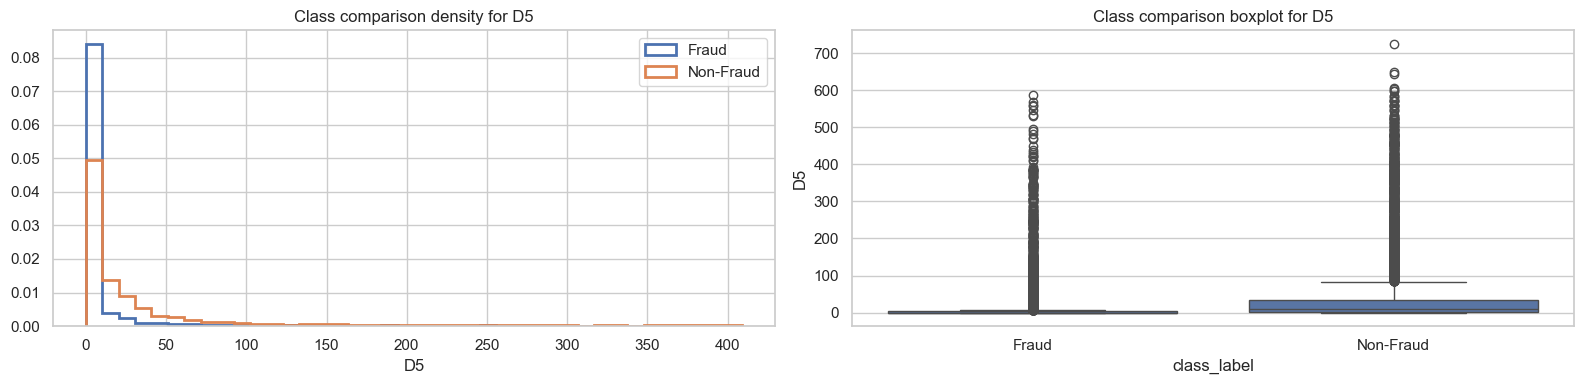

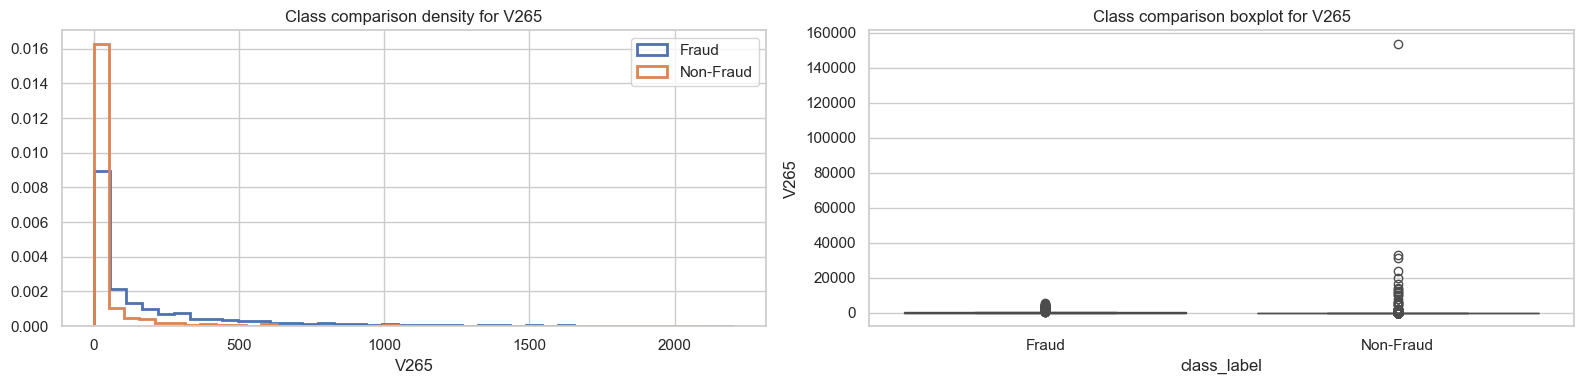

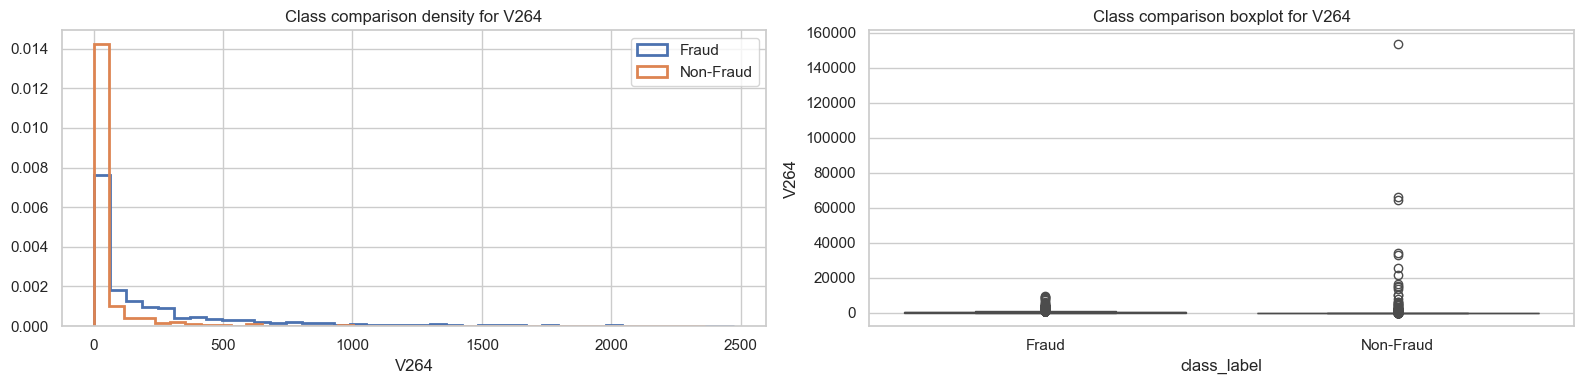

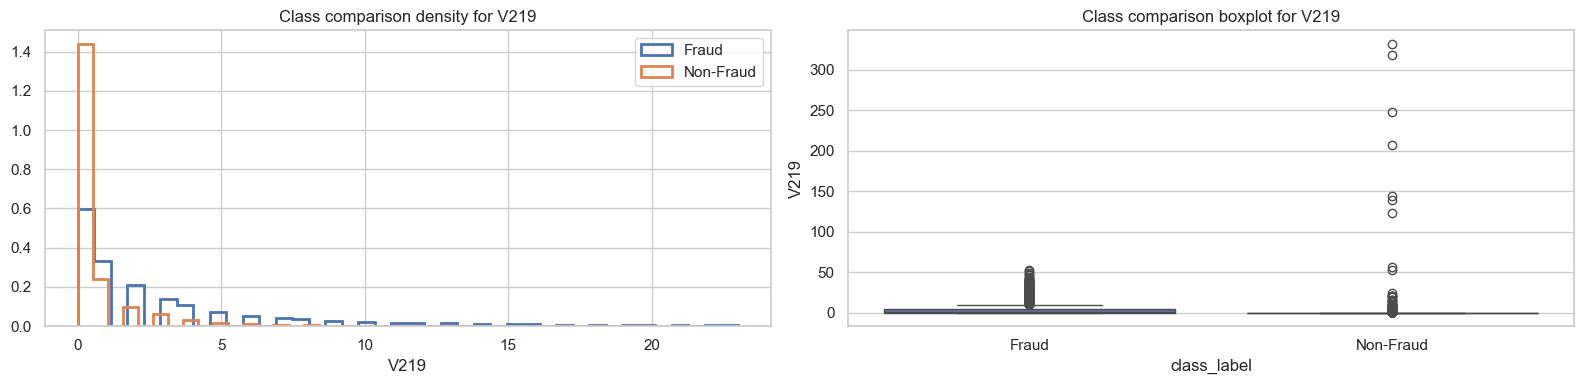

In [15]:
top_compare_features = (
    separation_table_full["feature"].head(MAX_COMPARE_NUMERIC).tolist()
    if not separation_table_full.empty
    else selected_numeric_features[:MAX_COMPARE_NUMERIC]
)

compare_missing_signal = []
for feature in top_compare_features:
    compare_missing_signal.append(
        {
            "feature": feature,
            "missing_pct_fraud": df_eda.loc[df_eda[target_col] == positive_class, feature].isna().mean(),
            "missing_pct_nonfraud": df_eda.loc[df_eda[target_col] != positive_class, feature].isna().mean(),
        }
    )

compare_missing_signal_df = pd.DataFrame(compare_missing_signal)
if not compare_missing_signal_df.empty:
    compare_missing_signal_df["fraud_minus_nonfraud_missing_pct"] = (
        compare_missing_signal_df["missing_pct_fraud"] - compare_missing_signal_df["missing_pct_nonfraud"]
    )

display(pd.DataFrame({"top_compare_features": top_compare_features}))
display(compare_missing_signal_df.sort_values("fraud_minus_nonfraud_missing_pct", key=lambda s: s.abs(), ascending=False))

balanced_numeric_plot_df = balanced_class_sample(
    df_eda[[target_col] + top_compare_features].dropna(how="all", subset=top_compare_features),
    target_col,
    per_class=BALANCED_PLOT_PER_CLASS,
)

for feature in top_compare_features:
    feature_values = pd.to_numeric(balanced_numeric_plot_df[feature], errors="coerce")
    plot_df = pd.DataFrame(
        {
            feature: feature_values,
            "class_label": np.where(
                balanced_numeric_plot_df[target_col] == positive_class,
                "Fraud",
                "Non-Fraud",
            ),
        }
    ).dropna()

    if plot_df.empty:
        continue

    density_df = plot_df.copy()
    if plot_df[feature].nunique() > 30:
        lower, upper = plot_df[feature].quantile([0.01, 0.99])
        density_df = plot_df[(plot_df[feature] >= lower) & (plot_df[feature] <= upper)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    for class_label, group in density_df.groupby("class_label"):
        axes[0].hist(group[feature], bins=40, density=True, histtype="step", linewidth=2, label=class_label)
    axes[0].set_title(f"Class comparison density for {feature}")
    axes[0].set_xlabel(feature)
    axes[0].legend()

    sns.boxplot(
        data=plot_df,
        x="class_label",
        y=feature,
        showfliers=True,
        ax=axes[1],
    )
    axes[1].set_title(f"Class comparison boxplot for {feature}")

    plt.tight_layout()
    plt.show()


### Phân tích kết quả

- Sáu biến numeric được đưa vào so sánh trực tiếp giữa fraud và non-fraud là:
  - `V258`, `V257`, `D5`, `V265`, `V264`, `V219`

  Đây chính là cụm feature đang có tín hiệu phân tách mạnh nhất trong notebook.
- Với `V258`, `V257`, `V265`, `V264`, `V219`, tỷ lệ missing:
  - ở fraud chỉ khoảng **50,68%**
  - ở non-fraud khoảng **78,90%**

  Chênh lệch gần **28,23 điểm phần trăm** là rất lớn. Insight ở đây là **sự hiện diện của feature** đã mang tín hiệu mạnh gần như ngang với giá trị của feature.
- `V257` và `V258` là hai biến rất đáng chú ý vì:
  - `ks_stat` cao
  - median fraud cao hơn hẳn non-fraud
  - correlation với target cũng thuộc nhóm đầu

  Điều này gợi ý chúng không chỉ phân biệt ở phần tail mà còn khác ngay trong vùng “thân” phân phối.
- `D5` có hành vi khác hẳn block `V*`:
  - fraud mean khoảng **13,85**
  - non-fraud mean khoảng **43,10**
  - fraud median = **0**
  - non-fraud median = **10**

  Nghĩa là với `D5`, fraud có xu hướng tập trung ở **mức thấp hơn**, chứ không phải ở vùng lớn bất thường. Đây là ví dụ điển hình cho một feature có tín hiệu nhưng **không đi cùng dấu trực giác “càng lớn càng rủi ro”**.
- `V264` và `V265` cho thấy non-fraud median bằng **0**, trong khi fraud median đã nhảy lên mức dương khá rõ. Điều này nói lên rằng fraud đang tập trung mạnh ở **đuôi phải / vùng kích hoạt**, chứ không chỉ chênh nhẹ quanh trung bình.

,feature
0,ProductCD


,ProductCD,transaction_count,fraud_count,fraud_rate
0,W,439670,8969,0.0204
1,C,68519,8008,0.1169
2,R,37699,1426,0.0378
3,H,33024,1574,0.0477
4,S,11628,686,0.0590


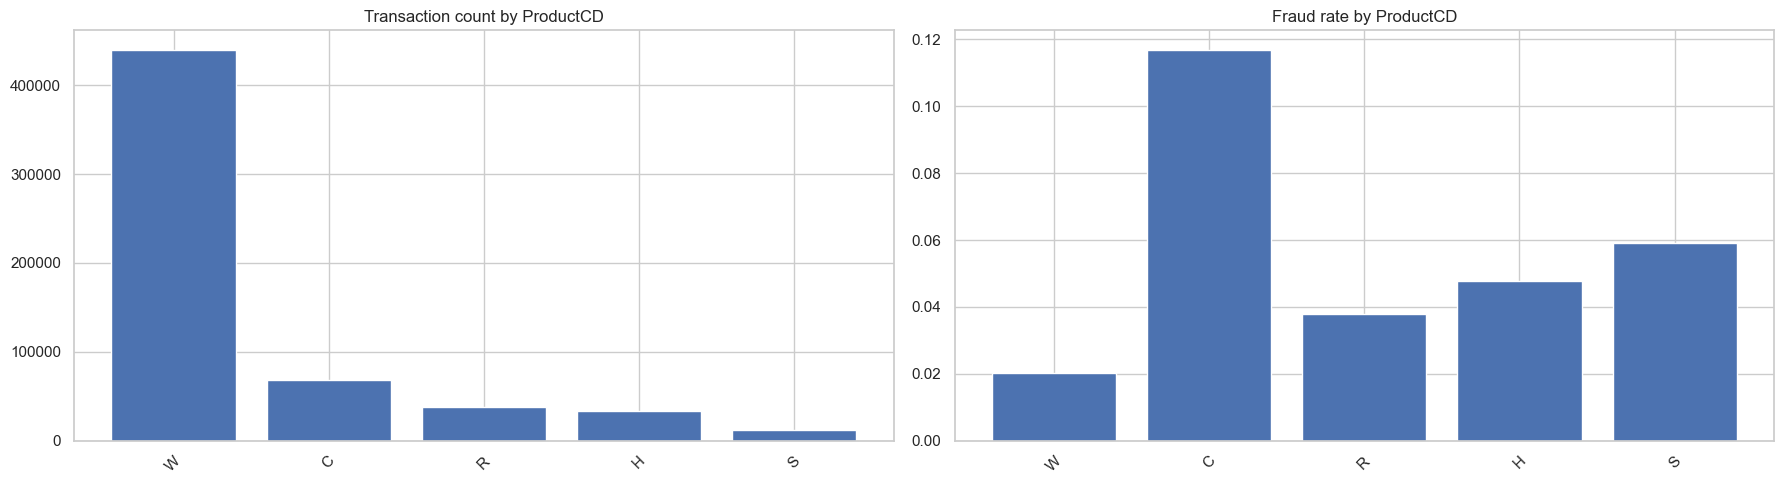

,feature
0,card4


,card4,transaction_count,fraud_count,fraud_rate
0,visa,384767,13373,0.0348
1,mastercard,189217,6496,0.0343
2,american express,8328,239,0.0287
3,discover,6651,514,0.0773
4,MISSING,1577,41,0.0260


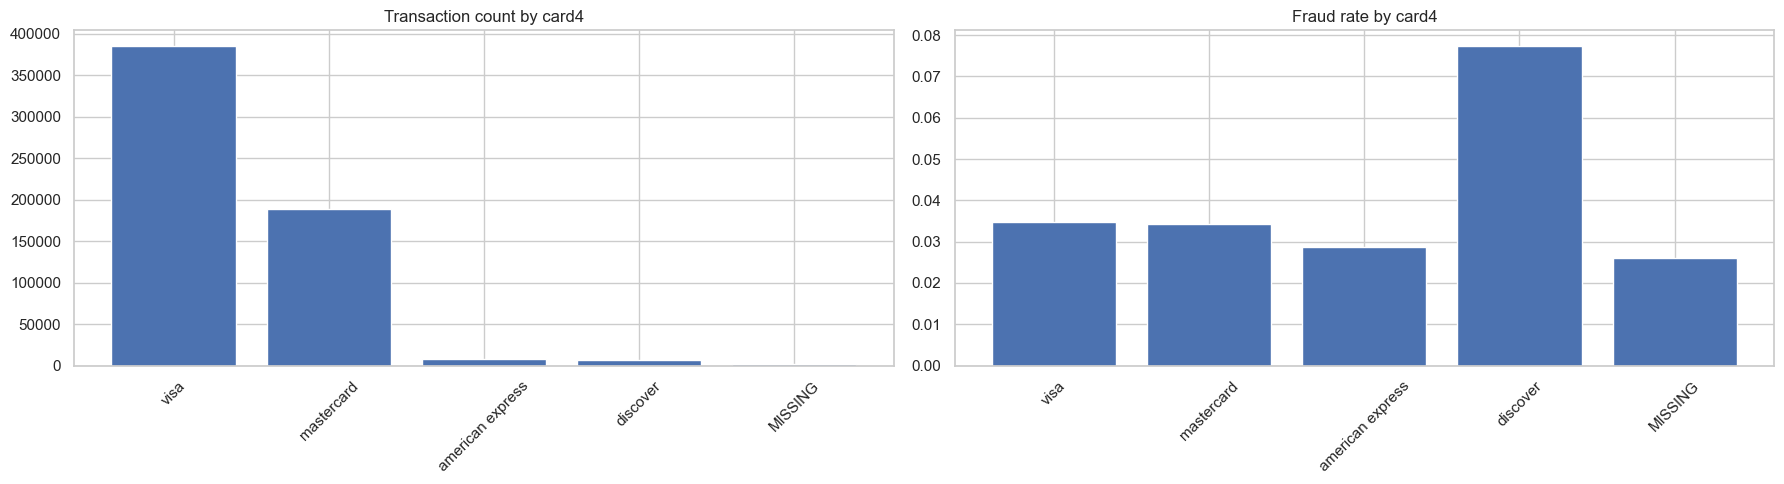

,feature
0,card6


,card6,transaction_count,fraud_count,fraud_rate
0,debit,439938,10674,0.0243
1,credit,148986,9950,0.0668
2,MISSING,1571,39,0.0248
3,OTHER,45,0,0.0000


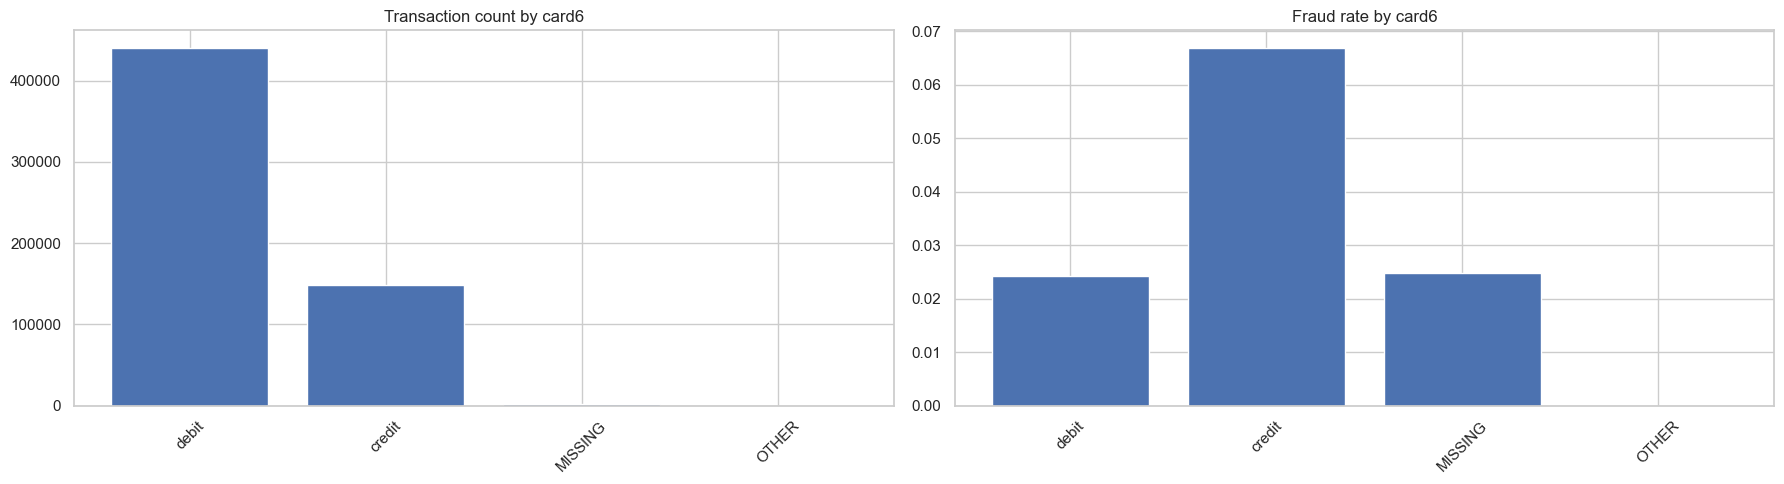

,feature
0,P_emaildomain


,P_emaildomain,transaction_count,fraud_count,fraud_rate
0,gmail.com,228355,9943,0.0435
1,yahoo.com,100934,2297,0.0228
2,MISSING,94456,2790,0.0295
3,hotmail.com,45250,2396,0.0530
4,anonymous.com,36998,859,0.0232
5,aol.com,28289,617,0.0218
6,OTHER,25841,632,0.0245
7,comcast.net,7888,246,0.0312
8,icloud.com,6267,197,0.0314
9,outlook.com,5096,482,0.0946


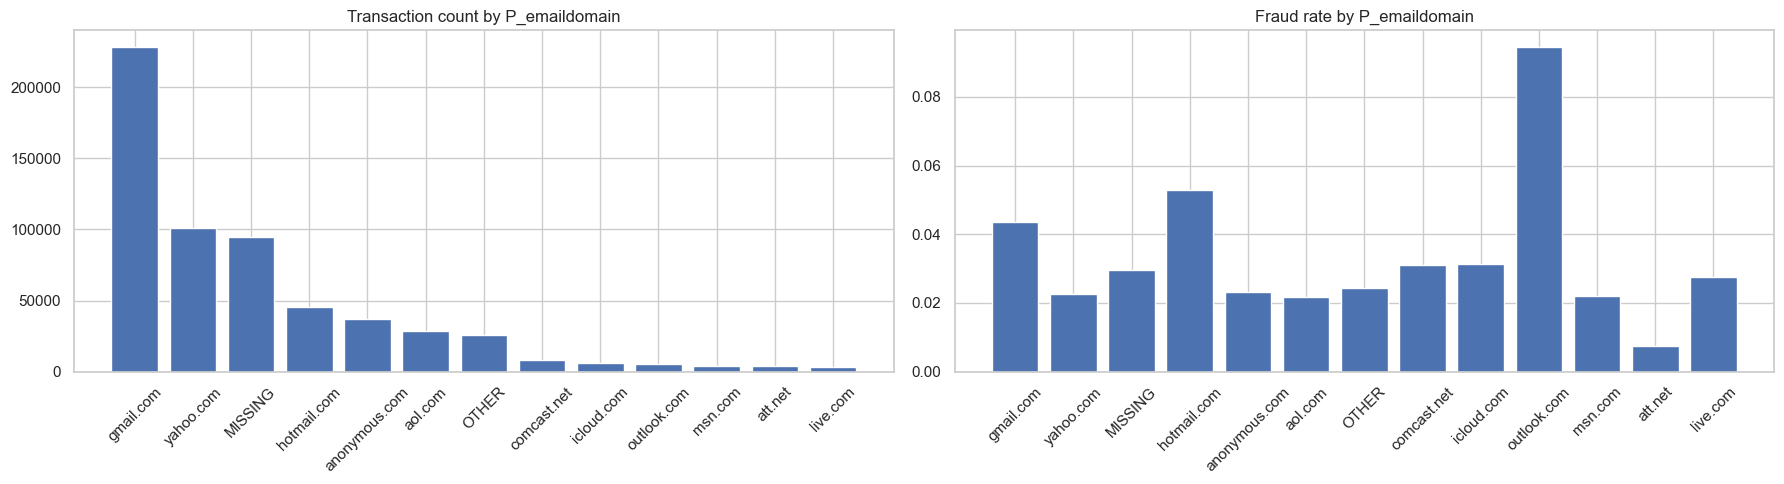

,feature
0,R_emaildomain


,R_emaildomain,transaction_count,fraud_count,fraud_rate
0,MISSING,453249,9436,0.0208
1,gmail.com,57147,6811,0.1192
2,hotmail.com,27509,2140,0.0778
3,anonymous.com,20529,598,0.0291
4,yahoo.com,11842,610,0.0515
5,OTHER,9338,308,0.0330
6,aol.com,3701,129,0.0349
7,outlook.com,2507,414,0.1651
8,comcast.net,1812,21,0.0116
9,yahoo.com.mx,1508,16,0.0106


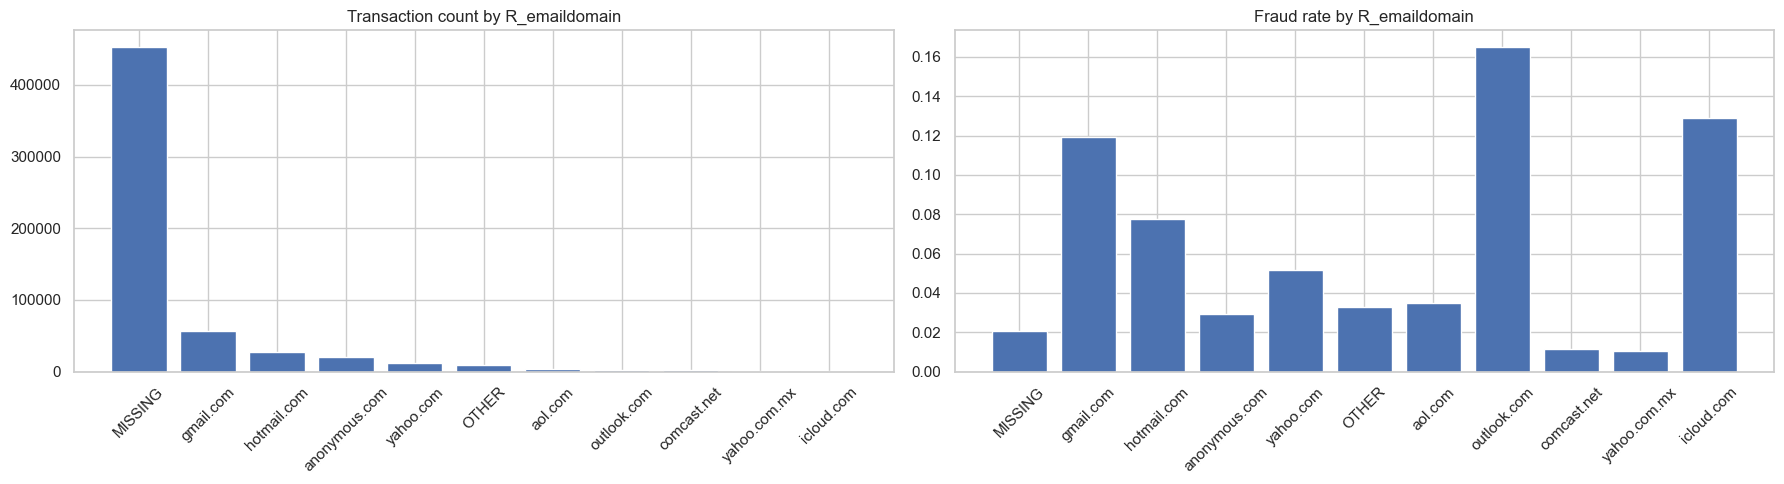

,feature
0,DeviceType


,DeviceType,transaction_count,fraud_count,fraud_rate
0,MISSING,449730,9452,0.0210
1,desktop,85165,5554,0.0652
2,mobile,55645,5657,0.1017


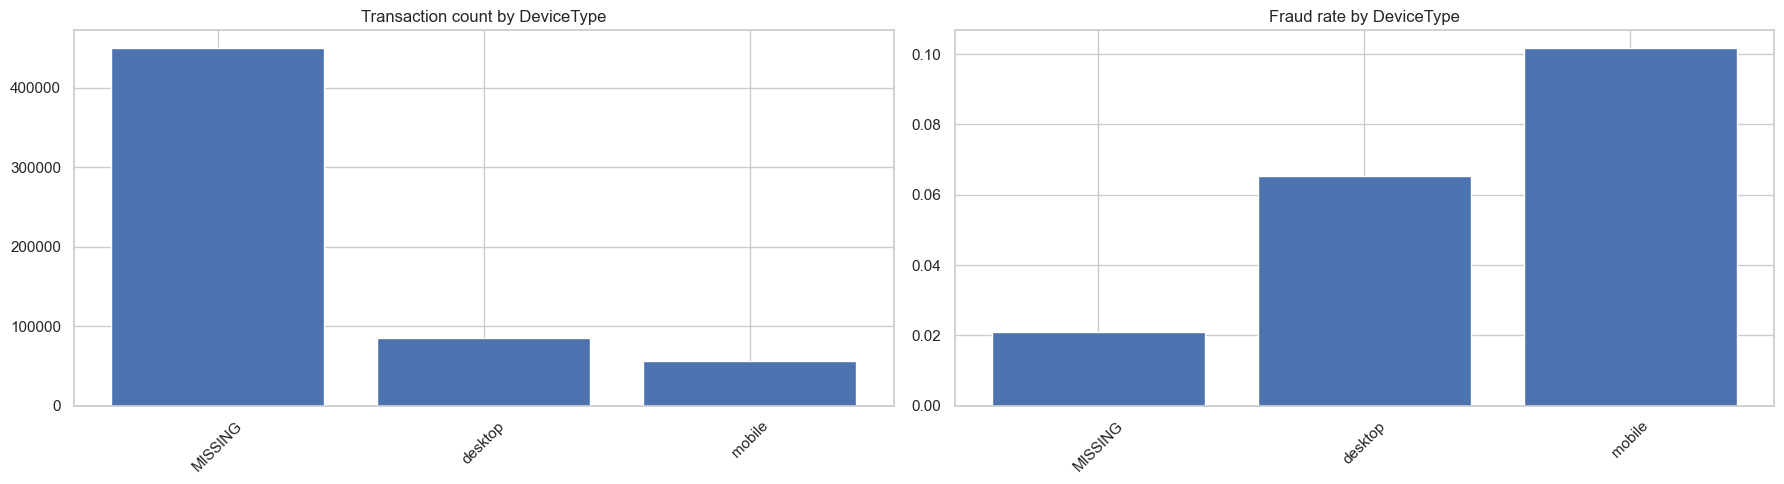

In [16]:
categorical_fraud_tables = {}

for feature in selected_categorical_features:
    fraud_table = category_fraud_table(
        df_eda,
        feature,
        target_col,
        positive_class,
        min_count=max(200, int(0.002 * len(df_eda))),
        top_n=12,
    )
    categorical_fraud_tables[feature] = fraud_table

    display(pd.DataFrame({"feature": [feature]}))
    display(fraud_table)

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    axes[0].bar(fraud_table[feature].astype(str), fraud_table["transaction_count"])
    axes[0].set_title(f"Transaction count by {feature}")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(fraud_table[feature].astype(str), fraud_table["fraud_rate"])
    axes[1].set_title(f"Fraud rate by {feature}")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


### Phân tích kết quả

#### 1. `ProductCD`

- `W` chiếm khoảng **74,45%** toàn bộ giao dịch nhưng fraud rate chỉ **2,04%**, thấp hơn đáng kể so với baseline **3,50%**.
- `C` chỉ chiếm khoảng **11,60%** volume nhưng fraud rate lên tới **11,69%**, tức cao hơn baseline khoảng **3,34 lần**.
- `S` (**5,90%**) và `H` (**4,77%**) cũng cao hơn baseline.

**Insight:** `ProductCD` là một trong những categorical feature rõ tín hiệu nhất. Volume lớn không đồng nghĩa rủi ro cao; ngược lại, một số nhóm nhỏ hơn đang gánh rủi ro fraud lớn hơn nhiều.

#### 2. `card4`

- `visa` và `mastercard` có fraud rate gần baseline (**~3,4%**).
- `discover` lên tới **7,73%**, tức khoảng **2,21 lần** baseline.

**Insight:** Network card type có khác biệt rủi ro đáng kể; không nên coi tất cả card brand là tương đương.

#### 3. `card6`

- `debit`: **2,43%**
- `credit`: **6,68%**

**Insight:** Giao dịch `credit` có fraud rate cao gần **1,9 lần** so với baseline và cao hơn rõ so với `debit`. Đây là một biến categorical nhỏ gọn nhưng giàu tín hiệu.

#### 4. `P_emaildomain`

- `outlook.com`: **9,46%**
- `hotmail.com`: **5,30%**
- `gmail.com`: **4,35%**
- `att.net`: **0,74%**

**Insight:** Email phía người mua có sự phân hóa rủi ro khá rõ. Không chỉ có volume, mà ngay cả domain cũng phản ánh chất lượng / kiểu hành vi giao dịch khác nhau.

#### 5. `R_emaildomain`

- `MISSING`: **2,08%**
- `gmail.com`: **11,92%**
- `hotmail.com`: **7,78%**
- `icloud.com`: **12,88%**
- `outlook.com`: **16,51%**

**Insight:** Đây là một trong những biến categorical mạnh nhất toàn notebook. Khi `R_emaildomain` hiện diện, fraud rate tăng rất mạnh; đặc biệt một số domain có mức rủi ro cao gấp nhiều lần baseline.

#### 6. `DeviceType`

- `MISSING`: **2,10%**
- `desktop`: **6,52%**
- `mobile`: **10,17%**

**Insight:** Thiết bị giao dịch là tín hiệu rất rõ. Giao dịch từ `mobile` có fraud rate gần **2,9 lần** baseline, còn `desktop` cũng cao khoảng **1,86 lần**. Trong khi đó, nhóm thiếu device info lại an toàn hơn mặt bằng chung.

### Nhận xét tổng hợp

Nhóm categorical đang cho thấy một bức tranh nhất quán: **metadata về kênh giao dịch, loại thiết bị, loại card và email domain** đều liên quan rõ tới xác suất fraud. Đây là nhóm biến rất đáng ưu tiên giữ lại vì:
- dễ diễn giải,
- dễ kiểm soát drift,
- và bổ sung góc nhìn nghiệp vụ cho các block `V*` khó hiểu.

## Correlation Analysis

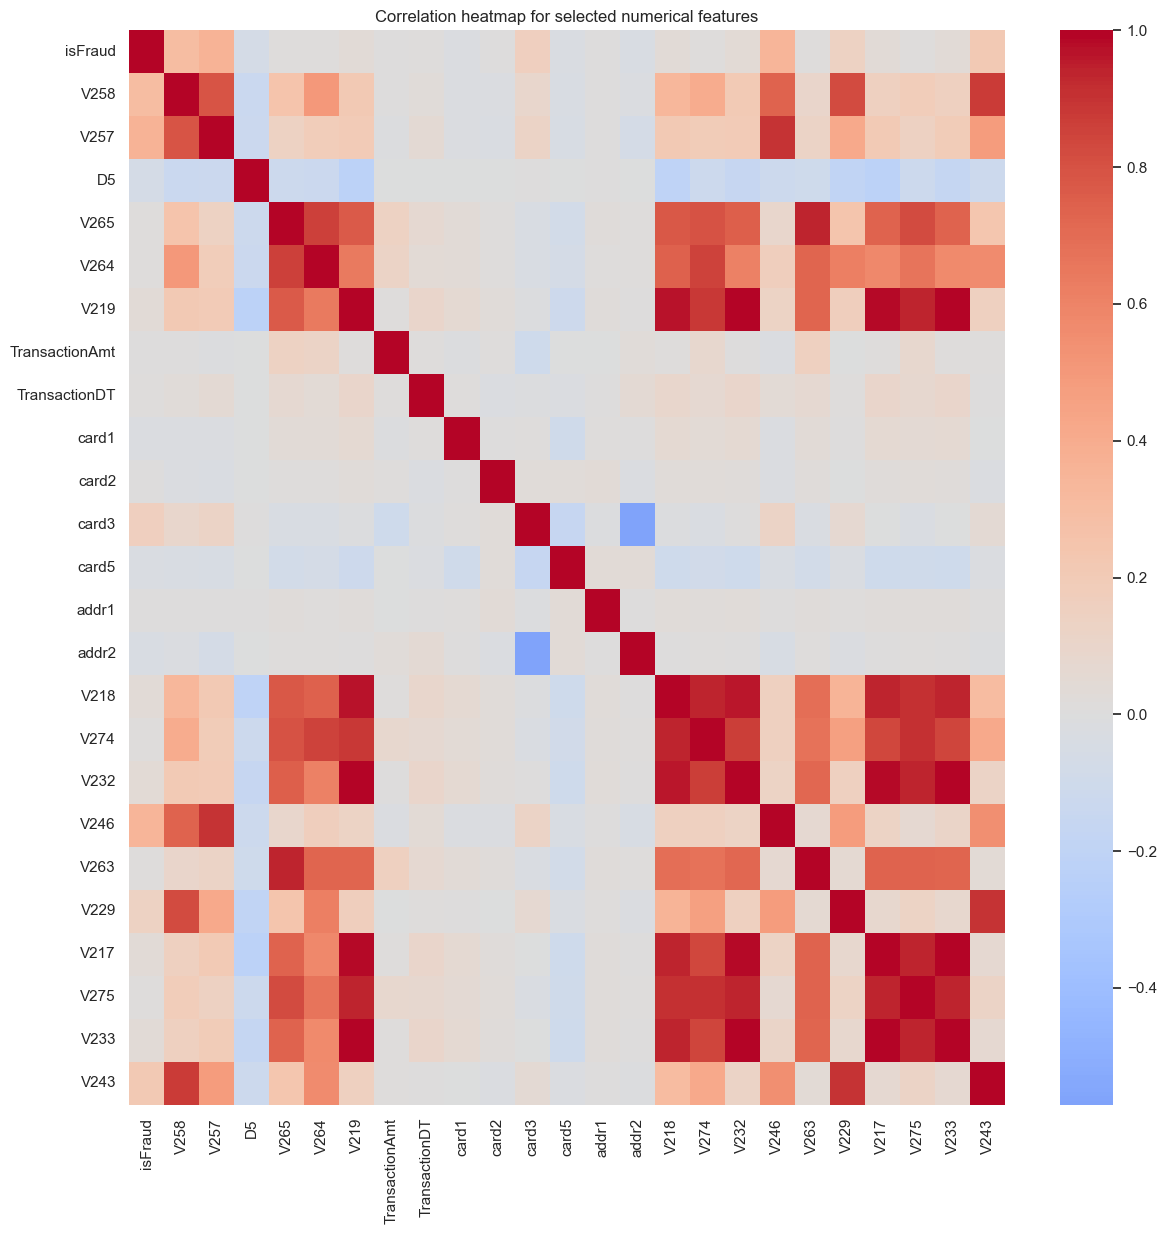

,corr_with_target,abs_corr_with_target
V257,0.3656,0.3656
V246,0.3468,0.3468
V258,0.2967,0.2967
V243,0.2093,0.2093
card3,0.1618,0.1618
V229,0.1378,0.1378
D5,-0.0647,0.0647
V232,0.0481,0.0481
V218,0.0417,0.0417
V233,0.0405,0.0405


,feature_1,feature_2,corr,abs_corr
0,V232,V233,0.9949,0.9949
1,V217,V233,0.9920,0.9920
2,V219,V232,0.9918,0.9918
3,V219,V233,0.9906,0.9906
4,V219,V217,0.9869,0.9869
5,V232,V217,0.9864,0.9864
6,V219,V218,0.9745,0.9745
7,V218,V232,0.9620,0.9620
8,V219,V275,0.9442,0.9442
9,V218,V233,0.9429,0.9429


In [17]:
corr_feature_candidates = []
for feature in top_compare_features + selected_numeric_features:
    if feature not in corr_feature_candidates and feature in eda_numeric_cols:
        corr_feature_candidates.append(feature)

for feature in separation_table_full["feature"].head(20).tolist() if not separation_table_full.empty else []:
    if feature not in corr_feature_candidates and feature in eda_numeric_cols:
        corr_feature_candidates.append(feature)

corr_feature_candidates = corr_feature_candidates[:MAX_CORR_FEATURES]
corr_columns = [target_col] + corr_feature_candidates

corr_sample = safe_sample(df_eda[corr_columns], n=min(100_000, len(df_eda)))
corr_matrix = corr_sample.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(max(10, len(corr_matrix) * 0.5), max(8, len(corr_matrix) * 0.5)))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap for selected numerical features")
plt.tight_layout()
plt.show()

if target_col in corr_matrix.columns:
    target_corr_table = (
        corr_matrix[[target_col]]
        .drop(index=[target_col], errors="ignore")
        .rename(columns={target_col: "corr_with_target"})
        .assign(abs_corr_with_target=lambda x: x["corr_with_target"].abs())
        .sort_values("abs_corr_with_target", ascending=False)
    )
else:
    target_corr_table = pd.DataFrame()

high_corr_pairs_df = correlation_pairs(
    corr_matrix.drop(index=[target_col], columns=[target_col], errors="ignore"),
    min_abs_corr=0.80,
)

display(target_corr_table.head(20))
display(high_corr_pairs_df.head(30))


### Phân tích kết quả

- Xét riêng tương quan tuyến tính với target, nhóm nổi bật nhất là:
  - `V257`: **0,3656**
  - `V246`: **0,3468**
  - `V258`: **0,2967**
  - `V243`: **0,2093**
  - `card3`: **0,1618**
  - `V229`: **0,1378**

  Điều này xác nhận rằng không chỉ phân phối khác nhau, một số biến `V*` còn có mối liên hệ tuyến tính khá rõ với nhãn fraud.
- `D5` là một trường hợp đáng chú ý:
  - ở phần separation trước đó rất mạnh,
  - nhưng correlation tuyến tính với target chỉ khoảng **-0,0647**.

  Insight ở đây là: `D5` có thể mang tín hiệu theo **threshold effect, shape effect hoặc nonlinear effect**, nên nếu chỉ nhìn correlation sẽ dễ đánh giá thấp nó.
- Bảng high-correlation pairs cho thấy một cụm redundancy rất mạnh:
  - `V232` – `V233`: **0,9949**
  - `V217` – `V233`: **0,9920**
  - `V219` – `V232`: **0,9918**
  - `V257` – `V246`: **0,9018**
  - `V265` – `V263`: **0,9369**
  - `V265` – `V264`: **0,8641**

  Đây là bằng chứng rõ ràng rằng nhiều feature trong block `V*` gần như đang mã hóa cùng một nguồn tín hiệu.
- Hàm ý trực tiếp là:
  - với mô hình tuyến tính, multicollinearity có thể gây bất ổn hệ số;
  - với mô hình cây, redundancy ít nguy hiểm hơn nhưng vẫn làm tăng độ phức tạp và giảm interpretability.

  Vì vậy screening / grouping / regularization cho các cụm `V*` là bước nên làm ở pha modeling.

## Outlier Analysis

,feature,lower_bound,upper_bound,outlier_pct_overall,outlier_pct_fraud,outlier_pct_nonfraud,fraud_minus_nonfraud_outlier_pct
0,V265,-31.3463,52.2438,0.0421,0.2592,0.0342,0.2250
1,V264,-50.3902,83.9837,0.0397,0.2417,0.0324,0.2093
2,V219,-1.5000,2.5000,0.0207,0.1768,0.0151,0.1617
3,D5,-45.5000,78.5000,0.0639,0.0243,0.0654,-0.0410


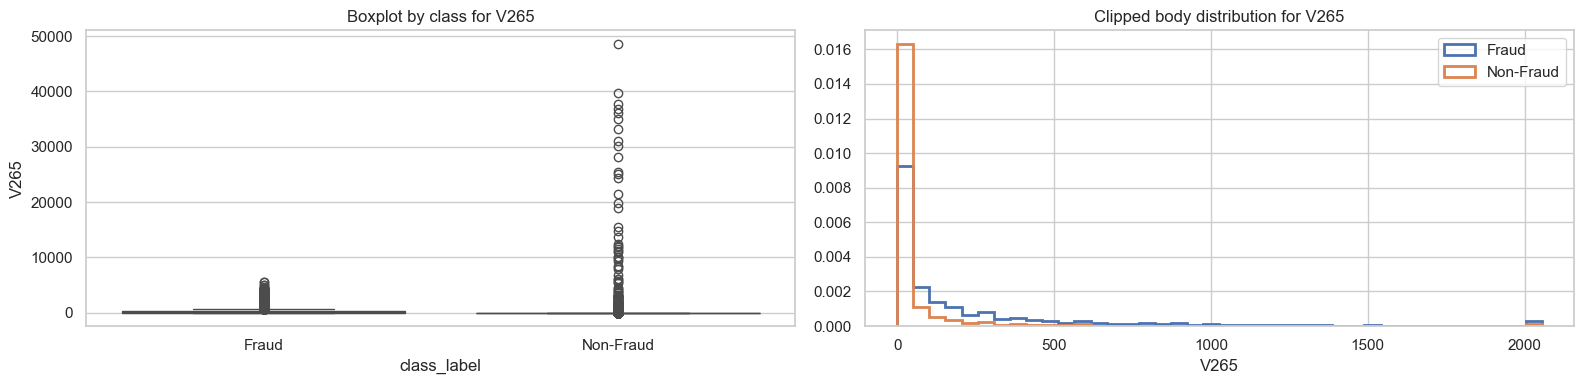

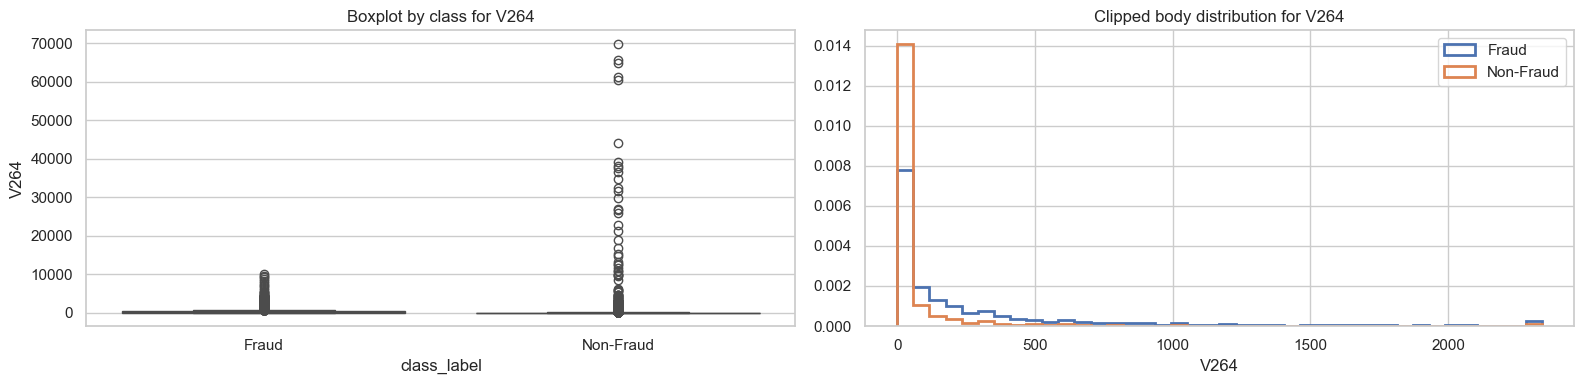

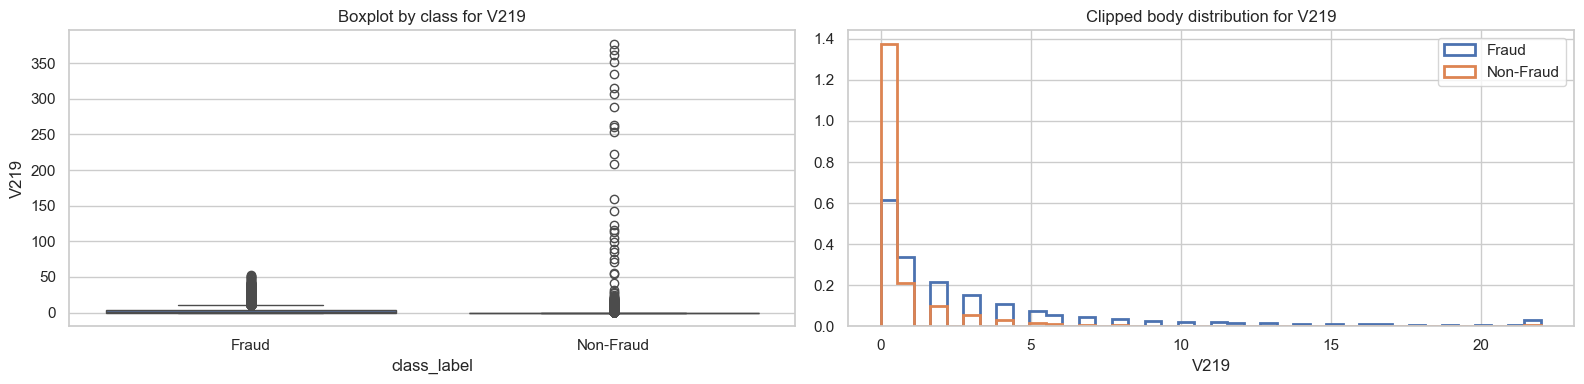

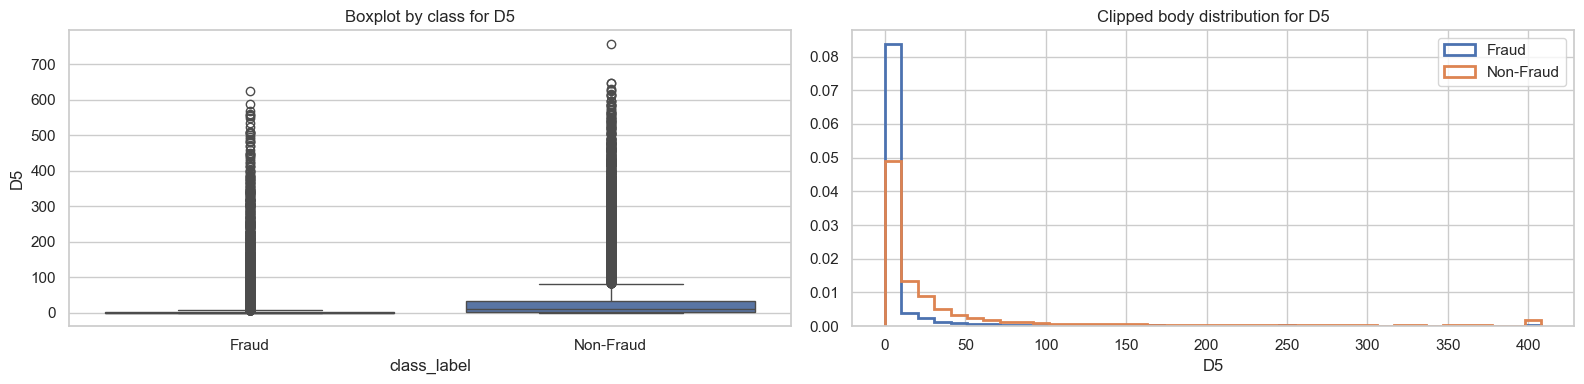

In [18]:
outlier_features = top_compare_features[:10]
outlier_table = outlier_summary_iqr(
    df_eda,
    outlier_features,
    target_col,
    positive_class,
)

display(outlier_table)

for feature in outlier_table["feature"].head(4).tolist() if not outlier_table.empty else []:
    plot_df = balanced_class_sample(
        df_eda[[target_col, feature]].dropna(),
        target_col,
        per_class=min(BALANCED_PLOT_PER_CLASS, 10_000),
    )

    lower_clip, upper_clip = plot_df[feature].quantile([0.01, 0.99])
    clipped_df = pd.DataFrame(
        {
            feature: plot_df[feature].clip(lower=lower_clip, upper=upper_clip),
            "class_label": np.where(plot_df[target_col] == positive_class, "Fraud", "Non-Fraud"),
        }
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    sns.boxplot(
        data=plot_df.assign(class_label=np.where(plot_df[target_col] == positive_class, "Fraud", "Non-Fraud")),
        x="class_label",
        y=feature,
        ax=axes[0],
    )
    axes[0].set_title(f"Boxplot by class for {feature}")

    for class_label, group in clipped_df.groupby("class_label"):
        axes[1].hist(group[feature], bins=40, density=True, histtype="step", linewidth=2, label=class_label)
    axes[1].set_title(f"Clipped body distribution for {feature}")
    axes[1].set_xlabel(feature)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


### Phân tích kết quả

- `V265`, `V264`, `V219` đều cho thấy outlier là vùng rất giàu tín hiệu:
  - `V265`: fraud outlier **25,92%** vs non-fraud **3,42%**
  - `V264`: fraud outlier **24,17%** vs non-fraud **3,24%**
  - `V219`: fraud outlier **17,68%** vs non-fraud **1,51%**

  Chênh lệch cỡ **16–22 điểm phần trăm** là quá lớn để xem đây chỉ là nhiễu.
- Đặc biệt, tỷ lệ outlier overall của các biến này chỉ khoảng **2–4%**, tức là vùng cực trị không phổ biến nhưng lại tập trung rất mạnh ở class fraud. Đây là mẫu hình kinh điển của fraud signal: **hiếm nhưng đậm**.
- `D5` cho kết quả ngược lại:
  - fraud outlier **2,43%**
  - non-fraud outlier **6,54%**

  Nghĩa là không phải mọi “điểm bất thường” đều làm tăng fraud risk. Với `D5`, vùng cực trị lại nghiêng về non-fraud; tín hiệu của biến này nằm ở **vị trí phân phối**, không phải ở phần tail quá lớn.
- Insight quan trọng nhất của cell này là: **không nên loại outlier một cách cơ học**. Với nhiều feature, especially trong block `V*`, phần outlier chính là nơi fraud tách mạnh nhất khỏi non-fraud.

## Time-based Analysis

,time_like_candidates
0,TransactionDT


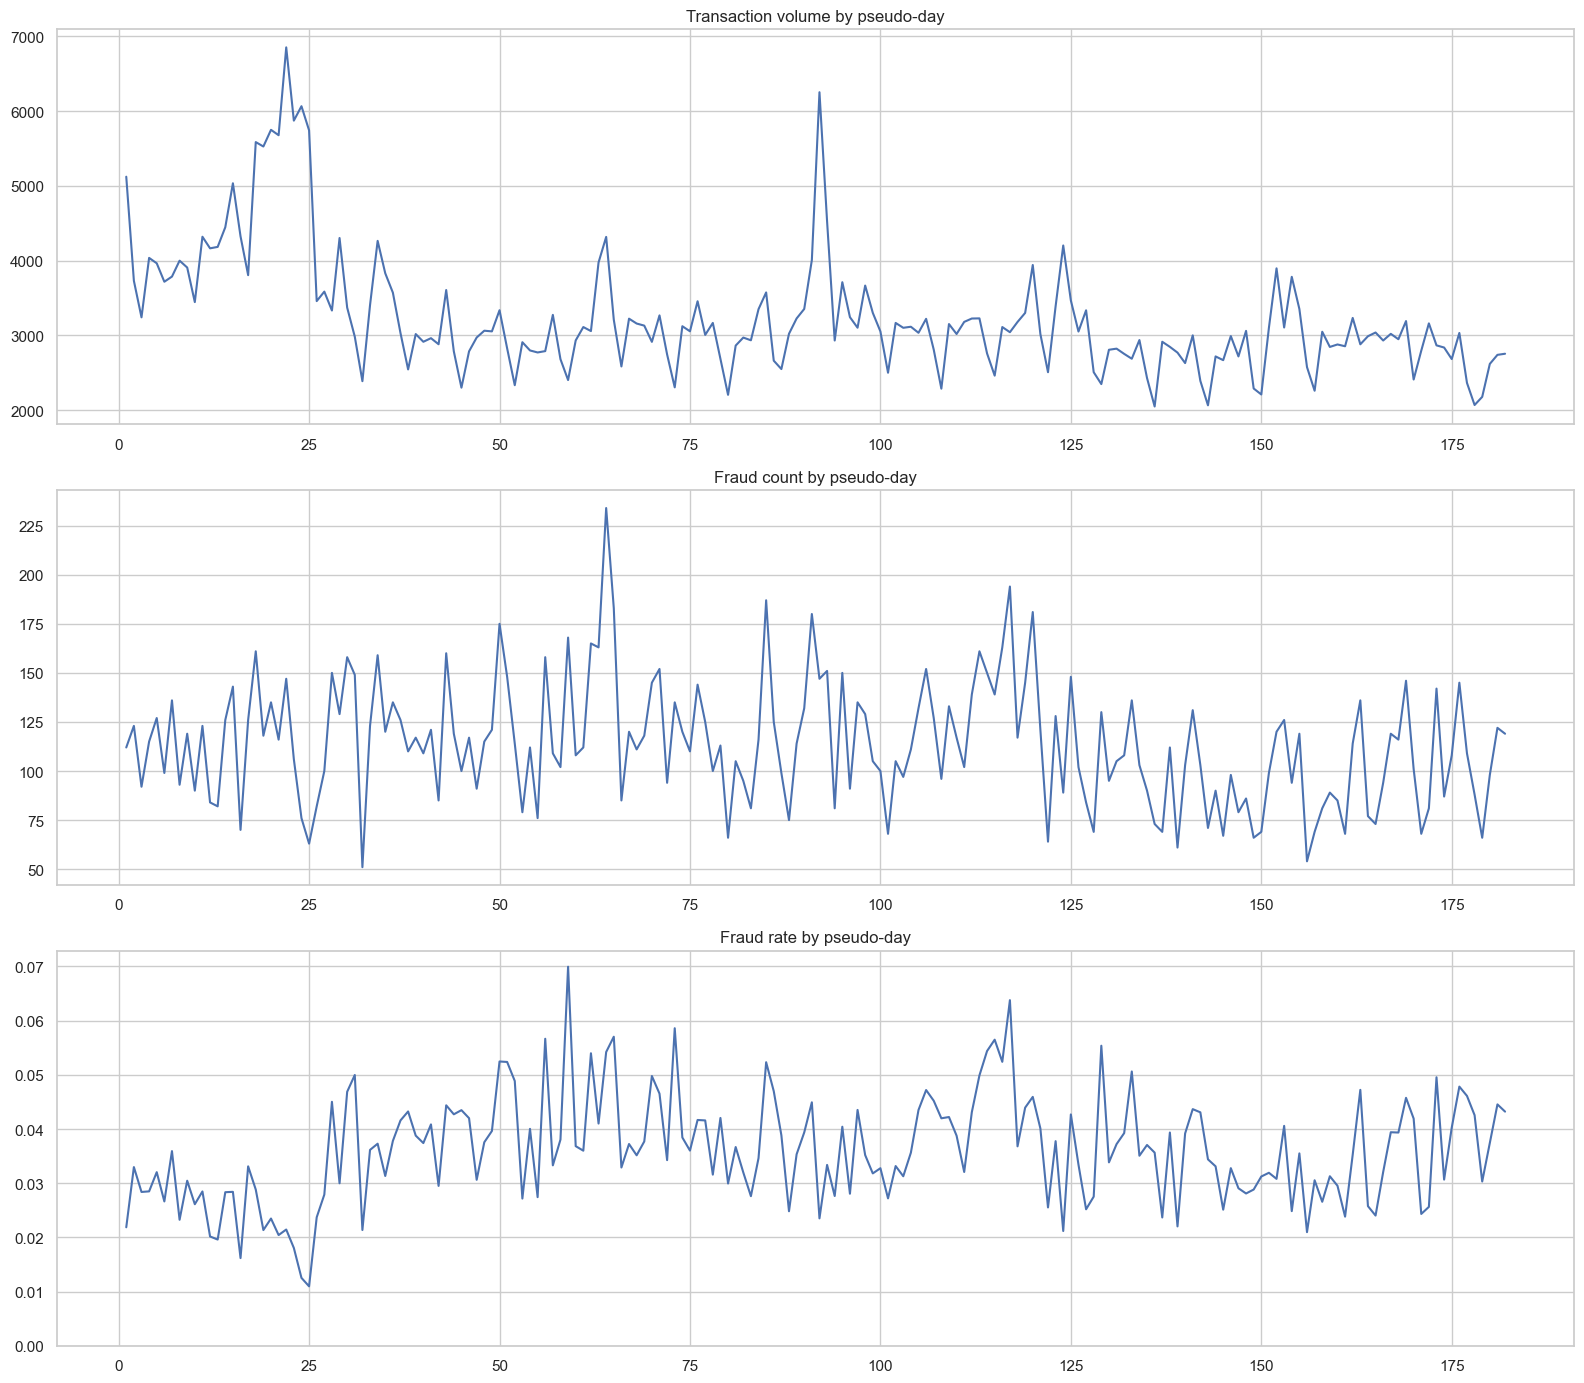

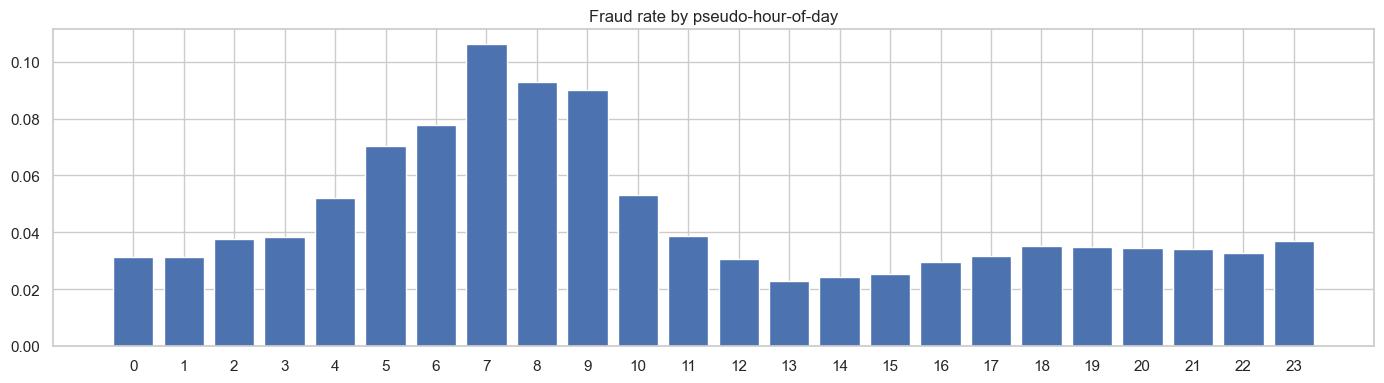

,pseudo_day,transaction_count,fraud_count,fraud_rate
0,1,5122,112,0.0219
1,2,3730,123,0.0330
2,3,3241,92,0.0284
3,4,4036,115,0.0285
4,5,3964,127,0.0320


,pseudo_hour_of_day,transaction_count,fraud_rate
0,0,37795,0.0314
1,1,32797,0.0313
2,2,26732,0.0375
3,3,20802,0.0383
4,4,14839,0.0519
5,5,9701,0.0703
6,6,6007,0.0777
7,7,3704,0.1061
8,8,2591,0.0930
9,9,2479,0.0900


,split,min_time,max_time
0,train,86400,15811131
1,test,18403224,34214345


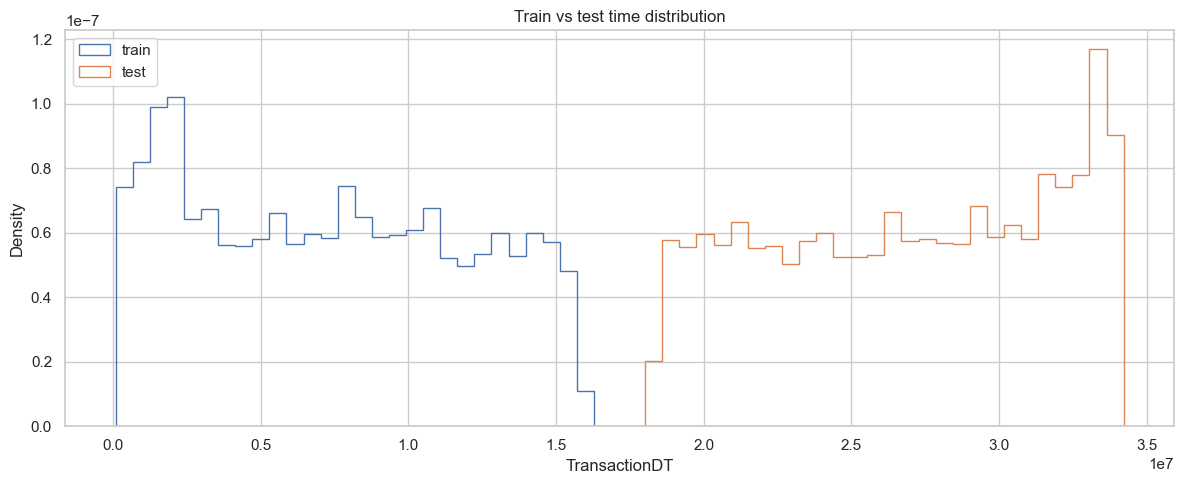

In [19]:
time_like_candidates = [col for col in df_eda.columns if re.search(r"(time|date|dt|timestamp)", str(col), flags=re.I)]
display(pd.DataFrame({"time_like_candidates": time_like_candidates}))

day_stats = pd.DataFrame()
hour_stats = pd.DataFrame()

if time_col is not None:
    day_stats, hour_stats = make_time_summary(df_eda, target_col, time_col, positive_class)

    if not day_stats.empty:
        fig, axes = plt.subplots(3, 1, figsize=(16, 14))

        axes[0].plot(day_stats["pseudo_day"], day_stats["transaction_count"])
        axes[0].set_title("Transaction volume by pseudo-day")

        axes[1].plot(day_stats["pseudo_day"], day_stats["fraud_count"])
        axes[1].set_title("Fraud count by pseudo-day")

        axes[2].plot(day_stats["pseudo_day"], day_stats["fraud_rate"])
        axes[2].set_title("Fraud rate by pseudo-day")
        axes[2].set_ylim(bottom=0)

        plt.tight_layout()
        plt.show()

    if not hour_stats.empty:
        plt.figure(figsize=(14, 4))
        plt.bar(hour_stats["pseudo_hour_of_day"].astype(str), hour_stats["fraud_rate"])
        plt.title("Fraud rate by pseudo-hour-of-day")
        plt.ylim(bottom=0)
        plt.tight_layout()
        plt.show()

    display(day_stats.head())
    display(hour_stats)

    test_transaction_path = resolved_paths["test_transaction"]
    if test_transaction_path is not None:
        test_time = pd.read_csv(
            test_transaction_path,
            usecols=[time_col],
            compression=compression_for_path(test_transaction_path),
            low_memory=False,
        )

        train_test_time_range = pd.DataFrame(
            {
                "split": ["train", "test"],
                "min_time": [df_eda[time_col].min(), test_time[time_col].min()],
                "max_time": [df_eda[time_col].max(), test_time[time_col].max()],
            }
        )

        display(train_test_time_range)

        train_time_sample = safe_sample(df_eda[[time_col]], n=min(100_000, len(df_eda)))[time_col].dropna()
        test_time_sample = safe_sample(test_time[[time_col]], n=min(100_000, len(test_time)))[time_col].dropna()

        bins = np.linspace(
            min(train_time_sample.min(), test_time_sample.min()),
            max(train_time_sample.max(), test_time_sample.max()),
            60,
        )

        plt.figure(figsize=(12, 5))
        plt.hist(train_time_sample, bins=bins, histtype="step", density=True, label="train")
        plt.hist(test_time_sample, bins=bins, histtype="step", density=True, label="test")
        plt.title("Train vs test time distribution")
        plt.xlabel(time_col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    display(pd.DataFrame({"message": ["No time column detected. Time-based analysis skipped."]}))


### Phân tích kết quả

- Notebook chỉ tìm thấy một time-like column thực sự hữu ích là `TransactionDT`. Điều này cho thấy toàn bộ góc nhìn thời gian của bài toán đang dồn về một trục chính duy nhất, nên việc khai thác đúng cột này sẽ rất quan trọng.
- Fraud rate theo giờ thay đổi rất mạnh:
  - giờ **5**: **7,03%**
  - giờ **6**: **7,77%**
  - giờ **7**: **10,61%**
  - giờ **8**: **9,30%**
  - giờ **9**: **9,00%**

  Trong khi đó nhiều giờ buổi trưa / chiều chỉ quanh **2,3% – 3,5%**. Nghĩa là rủi ro fraud **không đồng đều theo intraday cycle**, và chênh lệch này đủ lớn để ảnh hưởng trực tiếp tới threshold / alert policy.
- Các khung giờ có fraud rate cao lại đồng thời là những giờ có volume thấp hơn so với buổi chiều – tối. Điều đó gợi ý một dạng hành vi rủi ro: một số giao dịch xảy ra trong khung giờ “mỏng” nhưng lại có xác suất fraud cao hơn rõ rệt.
- Khoảng thời gian train và test bị tách rời:
  - train: `86400` → `15.811.131`
  - test: `18.403.224` → `34.214.345`

  Khoảng trống này là bằng chứng rất mạnh rằng random split sẽ không phản ánh đúng điều kiện triển khai. Nếu chia ngẫu nhiên, mô hình có thể học được pattern thời gian mà ngoài thực tế sẽ không còn giữ nguyên.
- Insight quan trọng nhất của phần này là: **time-aware validation là bắt buộc**, không phải tùy chọn.

## Variable Screening / Variables to Review

In [20]:
missing_signal_lookup = missing_signal_df.set_index("feature") if not missing_signal_df.empty else pd.DataFrame()
target_corr_lookup = target_corr_table["abs_corr_with_target"] if not target_corr_table.empty else pd.Series(dtype=float)
separation_lookup = separation_table_full.set_index("feature") if not separation_table_full.empty else pd.DataFrame()

all_top_freq = {}
for _, row in categorical_profile_df.iterrows():
    all_top_freq[row["feature"]] = row["top_freq_pct"]
for _, row in numeric_profile_df.iterrows():
    value_counts = df_eda[row["feature"]].value_counts(dropna=False, normalize=True)
    all_top_freq[row["feature"]] = value_counts.iloc[0] if not value_counts.empty else np.nan

drop_candidate_rows = []

for _, row in missing_eda[missing_eda["missing_pct"] >= 0.95].iterrows():
    feature = row["feature"]
    abs_missing_gap = missing_signal_lookup["abs_missing_gap"].get(feature, np.nan) if "abs_missing_gap" in missing_signal_lookup.columns else np.nan
    if pd.isna(abs_missing_gap) or abs_missing_gap < 0.02:
        drop_candidate_rows.append(
            {
                "feature": feature,
                "reason": "very_high_missing_without_class_signal",
                "metric_value": row["missing_pct"],
                "suggested_action": "strong_drop_candidate",
            }
        )

for feature in constant_columns:
    drop_candidate_rows.append(
        {
            "feature": feature,
            "reason": "constant_feature",
            "metric_value": 1.0,
            "suggested_action": "strong_drop_candidate",
        }
    )

for feature in quasi_constant_columns:
    if feature not in constant_columns:
        drop_candidate_rows.append(
            {
                "feature": feature,
                "reason": "quasi_constant_feature",
                "metric_value": all_top_freq.get(feature, np.nan),
                "suggested_action": "review_before_modeling",
            }
        )

drop_candidates_df = (
    pd.DataFrame(drop_candidate_rows)
    .drop_duplicates(subset=["feature", "reason"])
    .sort_values(["reason", "metric_value"], ascending=[True, False])
    .reset_index(drop=True)
    if drop_candidate_rows
    else pd.DataFrame(columns=["feature", "reason", "metric_value", "suggested_action"])
)

handle_carefully_rows = []

for _, row in missing_eda[missing_eda["missing_pct"] >= 0.90].iterrows():
    feature = row["feature"]
    abs_missing_gap = missing_signal_lookup["abs_missing_gap"].get(feature, np.nan) if "abs_missing_gap" in missing_signal_lookup.columns else np.nan
    if pd.notna(abs_missing_gap) and abs_missing_gap >= 0.02:
        handle_carefully_rows.append(
            {
                "feature": feature,
                "reason": "high_missing_with_class_signal",
                "metric_value": abs_missing_gap,
                "suggested_action": "keep_for_now_and_test_missing_indicator",
            }
        )

for _, row in numeric_anomaly_df[numeric_anomaly_df["abs_skew"] >= 10].iterrows():
    handle_carefully_rows.append(
        {
            "feature": row["feature"],
            "reason": "extreme_skew",
            "metric_value": row["abs_skew"],
            "suggested_action": "review_transform_or_tree_model_handling",
        }
    )

for _, row in outlier_table[outlier_table["fraud_minus_nonfraud_outlier_pct"].abs() >= 0.02].iterrows() if not outlier_table.empty else []:
    handle_carefully_rows.append(
        {
            "feature": row["feature"],
            "reason": "outlier_rate_differs_by_class",
            "metric_value": row["fraud_minus_nonfraud_outlier_pct"],
            "suggested_action": "do_not_blindly_clip_or_remove",
        }
    )

handle_carefully_df = (
    pd.DataFrame(handle_carefully_rows)
    .drop_duplicates(subset=["feature", "reason"])
    .sort_values(["reason", "metric_value"], ascending=[True, False])
    .reset_index(drop=True)
    if handle_carefully_rows
    else pd.DataFrame(columns=["feature", "reason", "metric_value", "suggested_action"])
)

redundancy_review_df = (
    high_corr_pairs_df[high_corr_pairs_df["abs_corr"] >= 0.95].copy()
    if not high_corr_pairs_df.empty
    else pd.DataFrame(columns=["feature_1", "feature_2", "corr", "abs_corr"])
)

lower_priority_df = pd.DataFrame(columns=["feature", "ks_stat", "norm_median_gap", "abs_target_corr", "missing_pct"])
if not separation_table_full.empty:
    lower_priority_df = separation_table_full[
        (separation_table_full["ks_stat"] <= 0.03)
        & (separation_table_full["norm_median_gap"] <= 0.05)
        & (separation_table_full["abs_target_corr"] <= 0.01)
        & (separation_table_full["missing_pct"] <= 0.50)
    ].copy()

display(drop_candidates_df.head(40))
display(handle_carefully_df.head(40))
display(redundancy_review_df.head(30))
display(lower_priority_df.head(30))


,feature,reason,metric_value,suggested_action
0,V305,quasi_constant_feature,1.0000,review_before_modeling
1,V107,quasi_constant_feature,0.9990,review_before_modeling
2,V117,quasi_constant_feature,0.9982,review_before_modeling
3,V119,quasi_constant_feature,0.9982,review_before_modeling
4,V118,quasi_constant_feature,0.9978,review_before_modeling
5,V120,quasi_constant_feature,0.9978,review_before_modeling
6,V122,quasi_constant_feature,0.9971,review_before_modeling
7,V111,quasi_constant_feature,0.9965,review_before_modeling
8,V113,quasi_constant_feature,0.9960,review_before_modeling
9,C3,quasi_constant_feature,0.9959,review_before_modeling


,feature,reason,metric_value,suggested_action
0,V311,extreme_skew,323.8314,review_transform_or_tree_model_handling
1,V129,extreme_skew,240.2743,review_transform_or_tree_model_handling
2,V309,extreme_skew,224.8753,review_transform_or_tree_model_handling
3,V206,extreme_skew,207.8816,review_transform_or_tree_model_handling
4,V319,extreme_skew,181.8336,review_transform_or_tree_model_handling
5,V269,extreme_skew,177.8389,review_transform_or_tree_model_handling
6,V266,extreme_skew,175.9588,review_transform_or_tree_model_handling
7,V334,extreme_skew,168.4728,review_transform_or_tree_model_handling
8,V135,extreme_skew,144.8832,review_transform_or_tree_model_handling
9,V321,extreme_skew,123.5565,review_transform_or_tree_model_handling


,feature_1,feature_2,corr,abs_corr
0,V232,V233,0.9949,0.9949
1,V217,V233,0.9920,0.9920
2,V219,V232,0.9918,0.9918
3,V219,V233,0.9906,0.9906
4,V219,V217,0.9869,0.9869
5,V232,V217,0.9864,0.9864
6,V219,V218,0.9745,0.9745
7,V218,V232,0.9620,0.9620


,feature,ks_stat,norm_median_gap,abs_target_corr,missing_pct,fraud_mean,nonfraud_mean,fraud_median,nonfraud_median
357,V135,0.0232,0.0000,0.0050,0.0005,16.9807,15.5332,0.0000,0.0000
365,V319,0.0168,0.0000,0.0051,0.0000,18.3721,16.7851,0.0000,0.0000
378,V25,0.0086,0.0000,0.0061,0.1288,0.9808,0.9783,1.0000,1.0000
381,V311,0.0064,0.0000,0.0015,0.0000,4.8568,5.3411,0.0000,0.0000
396,V1,0.0003,0.0000,0.0100,0.4729,1.0000,0.9997,1.0000,1.0000
398,V14,0.0003,0.0000,0.0069,0.1288,0.9998,0.9995,1.0000,1.0000
399,V88,0.0002,0.0000,0.0045,0.1510,0.9994,0.9991,1.0000,1.0000
400,V107,0.0001,0.0000,0.0022,0.0005,0.9998,0.9999,1.0000,1.0000


### Phân tích kết quả

- Nhóm ứng viên loại bỏ mạnh (`strong_drop_candidate`) chủ yếu là các cột:
  - `id_24`, `id_25`, `id_07`, `id_08`, `id_21`, `id_26`, `id_22`, `id_23`, `id_27`, ...

  Các cột này vừa **missing cực cao (~99%)** vừa không cho thấy class-signal đủ rõ để biện minh việc giữ lại.
- Nhóm quasi-constant như `V305`, `V107`, `V117`–`V122`, `C3` được đánh dấu `review_before_modeling` chứ chưa drop thẳng. Đây là quyết định hợp lý vì chúng có độ biến thiên rất thấp, nhưng vẫn nên kiểm tra chéo với target signal trước khi loại hoàn toàn.
- Danh sách `handle carefully` bị chi phối bởi các biến extreme-skew như:
  - `V311`, `V129`, `V309`, `V206`, `V319`, `V269`, `V266`, `V334`, ...

  Insight ở đây là các biến này không bị gắn nhãn “drop”, mà được xếp vào nhóm **cần xử lý cẩn thận**. Tức là vấn đề của chúng nằm ở hình dạng phân phối, không nhất thiết ở giá trị thông tin.
- Bảng redundancy review tiếp tục lặp lại cụm tương quan cực mạnh quanh `V217`, `V218`, `V219`, `V232`, `V233`. Điều này xác nhận rằng bước screening không chỉ nhìn từng feature riêng lẻ, mà còn nhìn cả **trùng lặp thông tin giữa các feature**.
- Nhóm `lower-priority` gồm các biến như `V135`, `V319`, `V25`, `V311`, `V1`, `V14`, `V88`, `V107` cho thấy một điểm đáng nhớ: **một biến có thể rất skew hoặc nhìn “phức tạp”, nhưng vẫn không phân tách class tốt**. Đây là lý do screening theo nhiều tiêu chí cùng lúc quan trọng hơn chỉ nhìn một metric đơn lẻ.

## EDA Summary

In [21]:
screening_counts = pd.DataFrame(
    {
        "screening_bucket": [
            "drop_candidates",
            "handle_carefully",
            "redundancy_pairs",
            "lower_priority_numeric_features",
        ],
        "count": [
            len(drop_candidates_df),
            len(handle_carefully_df),
            len(redundancy_review_df),
            len(lower_priority_df),
        ],
    }
)

top_signal_features = separation_table_full.head(10).copy() if not separation_table_full.empty else pd.DataFrame()
if not top_signal_features.empty and not target_corr_table.empty:
    top_signal_features = top_signal_features.merge(
        target_corr_table[["abs_corr_with_target"]],
        left_on="feature",
        right_index=True,
        how="left",
    )

summary_table = pd.DataFrame(
    {
        "metric": [
            "data_mode",
            "unit_of_analysis",
            "rows_in_df_eda",
            "columns_in_df_eda",
            "target_col",
            "positive_class",
            "fraud_ratio",
            "nonfraud_to_fraud_ratio",
            "numeric_features",
            "categorical_features",
            "columns_missing_ge_90pct",
            "duplicate_full_rows",
            f"duplicate_{id_col}" if id_col else "duplicate_id",
        ],
        "value": [
            data_mode,
            "transaction",
            df_eda.shape[0],
            df_eda.shape[1],
            target_col,
            positive_class,
            fraud_ratio,
            imbalance_ratio,
            len(eda_numeric_cols),
            len(eda_categorical_cols),
            int((missing_eda["missing_pct"] >= 0.90).sum()),
            int(df_eda.duplicated().sum()),
            int(df_eda[id_col].duplicated().sum()) if id_col else np.nan,
        ],
    }
)

next_modeling_checklist = pd.DataFrame(
    {
        "priority": [
            "Use time-aware validation if TransactionDT is meaningful",
            "Track PR-AUC in addition to Recall, Precision and F1-score",
            "Tune decision threshold instead of relying on 0.5",
            "Treat missingness as potential signal, not only as nuisance",
            "Do not remove outliers mechanically",
            "Review highly correlated pairs for redundancy",
            "Review extreme-skew variables before non-tree models",
        ]
    }
)

display(summary_table)
display(screening_counts)
display(top_signal_features)
display(next_modeling_checklist)


,metric,value
0,data_mode,train_transaction LEFT JOIN train_identity on TransactionID
1,unit_of_analysis,transaction
2,rows_in_df_eda,590540
3,columns_in_df_eda,435
4,target_col,isFraud
5,positive_class,1
6,fraud_ratio,0.0350
7,nonfraud_to_fraud_ratio,27.5796
8,numeric_features,402
9,categorical_features,31


,screening_bucket,count
0,drop_candidates,20
1,handle_carefully,213
2,redundancy_pairs,8
3,lower_priority_numeric_features,8


,feature,ks_stat,norm_median_gap,abs_target_corr,missing_pct,fraud_mean,nonfraud_mean,fraud_median,nonfraud_median,abs_corr_with_target
0,V258,0.4679,0.5000,0.2452,0.7791,3.4151,1.2174,2.0000,1.0000,0.2967
1,V257,0.4385,1.0000,0.2501,0.7791,2.9698,1.1122,2.0000,1.0000,0.3656
2,D5,0.4355,0.6250,0.1979,0.5247,13.8545,43.0959,0.0000,10.0000,0.0647
3,V265,0.4210,0.3669,0.0551,0.7791,232.2929,130.4737,62.3810,0.0000,0.0130
4,V264,0.4205,0.3942,0.0236,0.7791,274.5869,197.5187,78.8481,0.0000,0.0085
5,V219,0.4194,0.3333,0.2049,0.7791,3.2863,0.8333,1.0000,0.0000,0.0404
6,V218,0.4181,0.6667,0.1662,0.7791,4.0145,1.1989,2.0000,0.0000,0.0417
7,V274,0.4068,0.2019,0.0628,0.7791,174.6187,83.2219,20.7844,0.0000,0.0136
8,V232,0.4062,0.5000,0.2050,0.7791,2.9833,0.5006,1.0000,0.0000,0.0481
9,V246,0.4035,0.0000,0.2393,0.7791,2.4993,1.0817,1.0000,1.0000,0.3468


,priority
0,Use time-aware validation if TransactionDT is meaningful
1,"Track PR-AUC in addition to Recall, Precision and F1-score"
2,Tune decision threshold instead of relying on 0.5
3,"Treat missingness as potential signal, not only as nuisance"
4,Do not remove outliers mechanically
5,Review highly correlated pairs for redundancy
6,Review extreme-skew variables before non-tree models


### Phân tích kết quả

- Summary table chốt lại bức tranh dữ liệu ở mức cao:
  - **590.540** giao dịch
  - **435** cột
  - **402** numeric features
  - **31** categorical features
  - **12** cột có missing trên **90%**
  - không có duplicate rows hay duplicate `TransactionID`

  Đây là một dataset lớn, nhiều feature, khá sạch về mặt cấu trúc, nhưng rất khó ở khía cạnh sparsity và feature geometry.
- Screening bucket counts rất đáng chú ý:
  - `drop_candidates`: **20**
  - `handle_carefully`: **213**
  - `redundancy_pairs`: **8**
  - `lower_priority_numeric_features`: **8**

  Tức là số cột nên loại ngay thực ra không nhiều; phần khó nhất nằm ở **hơn 200 cột cần xử lý có chủ đích**, không phải ở việc dọn vài cột xấu rồi xong.
- Top signal features được summary xác nhận lại gồm:
  - `V258`, `V257`, `D5`, `V265`, `V264`, `V219`, `V218`, `V274`, `V232`, `V246`

  Trong nhóm này:
  - `V257`, `V246`, `V258` nổi bật vì vừa tách class tốt vừa có correlation khá mạnh;
  - `V264`, `V265` lại cho thấy tín hiệu mạnh chủ yếu qua **shape / tail / activation region**, chứ không phải chỉ qua correlation tuyến tính.
- Checklist modeling ở cuối summary bám rất sát đúng những gì EDA đã phát hiện:
  - dùng time-aware validation,
  - theo dõi PR-AUC,
  - tune threshold,
  - giữ missingness như tín hiệu,
  - không loại outlier máy móc,
  - rà soát tương quan cao,
  - xử lý extreme skew trước khi dùng mô hình không phải cây.

Nói ngắn gọn, EDA đã đủ rõ để định hình pipeline tiếp theo: **giảm ít, giữ nhiều, nhưng xử lý có chiến lược**.

## Final Conclusion

### Kết luận tổng hợp

Phần EDA này cho thấy bài toán fraud detection trong bộ IEEE-CIS không khó vì thiếu dữ liệu, mà khó vì **tín hiệu nằm trong một cấu trúc rất bất đối xứng**:

- **Target cực lệch**, với fraud chỉ khoảng **3,50%**, nên accuracy tự thân gần như không có giá trị diễn giải.
- **Missingness không ngẫu nhiên**. Nhiều nhóm biến `id_*`, `Device*`, `R_emaildomain` và một cụm lớn `V*` không chỉ thiếu nhiều, mà còn có mô hình thiếu khác biệt rõ giữa fraud và non-fraud.
- **Tín hiệu mạnh nhất tập trung ở một số biến `V*` và `D5`**, đặc biệt `V258`, `V257`, `V246`, `V219`, `V232`, `V233`, `V264`, `V265`. Tuy nhiên các biến này lại đi kèm hai đặc điểm khó: **missing cao** và **tương quan nội khối rất mạnh**.
- **Categorical feature vẫn rất hữu ích**, nhất là `ProductCD`, `card6`, `R_emaildomain`, `DeviceType`. Đây là nhóm biến diễn giải được bằng nghiệp vụ và tạo chênh lệch fraud rate khá rõ.
- **Outlier nhiều khi chính là tín hiệu fraud**, nhất là ở `V264`, `V265`, `V219`, nên không thể dùng tư duy “lọc sạch ngoại lệ” một cách máy móc.
- **Fraud rate thay đổi theo thời gian trong ngày** và train/test nằm trên **hai cửa sổ thời gian tách biệt**, vì vậy đánh giá mô hình theo random split sẽ dễ lạc quan giả tạo.

### Hàm ý trực tiếp cho bước tiếp theo

1. **Validation**
   - Ưu tiên **time-aware split** hoặc forward-chaining validation.
   - Theo dõi **PR-AUC, Precision, Recall, F1**, không dùng accuracy làm metric trung tâm.

2. **Missingness handling**
   - Giữ `NaN` như một trạng thái mang thông tin đối với nhiều cột.
   - Cân nhắc tạo **missing indicator** cho các biến có missing gap lớn theo class.
   - Chỉ loại những cột quá thiếu mà đồng thời **không có class-signal rõ**.

3. **Feature preprocessing**
   - Với nhóm cực lệch / spike-at-zero: ưu tiên **log-like transform, clipping có kiểm soát**, hoặc dùng mô hình cây.
   - Với nhóm tương quan rất cao: cân nhắc **feature pruning / grouping / regularization**.
   - Với categorical: giữ rõ mức **MISSING / OTHER** thay vì ép nội suy.

4. **Modeling direction**
   - Một baseline tốt nên tận dụng được:
     - missingness,
     - nonlinear threshold effects,
     - tail behavior,
     - interaction giữa device / email / transaction context.
   - Vì vậy, các mô hình cây tăng cường như **LightGBM / XGBoost / CatBoost** sẽ là điểm khởi đầu hợp lý hơn mô hình tuyến tính thuần.